##  <font color="green">Redes Neuronales Recurrentes
El objetivo de esta sección es aprender y practicar redes neuronales recurrentes (RNN) en diversas tareas y aplicaciones, siendo la primera de ellas el análisis de datos de series temporales. Las RNN han revolucionado la forma en que se pronostica la información secuencial.

ver este enlace animado https://joshvarty.github.io/VisualizingRNNs/



En una red neuronal recurrente, se guardan (memoria) las activaciones de salida de una o más capas de la red. A menudo, estas activaciones son de las capas ocultas. Luego, la próxima vez que alimentamos un ejemplo de entrada a la red, incluimos las salidas almacenadas previamente como entradas adicionales. Estas entradas adicionales como si estuvieran concatenadas al final de las entradas “normales” de la capa anterior.

 Por ejemplo, si una capa oculta tiene 10 nodos de entrada regulares y 128 nodos ocultos en la capa, entonces tendría en realidad un total de 138 entradas. Por supuesto, la primera vez que intentas calcular la salida de la red, necesitarás rellenar esas 128 entradas adicionales con ceros o algo similar.

![image](https://github.com/adiacla/RNN/blob/main/rnn.png?raw=true)



Las redes neuronales recurrentes (En inglés Recurrent Neural Networks - RNN) son una familia de redes neuronales para procesar datos secuenciales, las cuales se basan en el principio de compartir parámetros a lo largo de diferentes partes del modelo, lo que permite aplicar el modelo a datos con estructuras diferentes y generalizar sobre ellos.

Si por el contrario se tuviera un párametro para cada índice de tiempo, no se podría generalizar a longitudes de secuencias no vistas durante el entrenamiento, o compartir patrones detectados por el modelo a lo largo de diferentes longitudes de secuencias y posiciones en el tiempo; dicha propiedad es particularmente importante cuando una pieza de información específica puede ocurrir en múltiples posiciones dentro de una secuencia.

La red permanece Feed-forward pero mantiene el estado interno a través de nodos de contexto los cuales influencian la capa oculta en entradas subsecuentes. Existen diferentes arquitecturas de RNN, las más conocidas son las Elman y Jordan como se aprecia la siguiente imagen.

![image](https://raw.githubusercontent.com/jdariasl/ML_2020/a4f7f015e29b279db380dd51f1a5e379fd3d4ae4//Images/RNN2.png)

#Tipos de RNN
Las redes prealimentadas tienen entrada y salida únicas, mientras que las redes neuronales recurrentes son flexibles, ya que se puede cambiar la longitud de las entradas y las salidas. Esta flexibilidad permite a las RNN generar música, clasificación de sentimiento y traducción automática.

Hay cuatro tipos de RNN basados en diferentes longitudes de entradas y salidas.

**Uno a uno** es una red neuronal sencilla. Se suele utilizar para problemas de machine learning que tienen entrada y salida únicas.
Uno a muchos tiene entrada única y varias salidas. Se utiliza  por ejemplo en generar comentarios de foto.

**Muchos a uno** toma una secuencia de varias entradas y predice una salida única. Es popular en la clasificación de sentimiento, donde la entrada es texto y la salida es una categoría.

**Muchos a muchos** toma varias entradas y salidas. La aplicación más común es la traducción automática.

![image](https://raw.githubusercontent.com/jdariasl/ML_2020/a4f7f015e29b279db380dd51f1a5e379fd3d4ae4/Images/RNN-Topol.jpeg)

Retomando la definición, una red neuronal recurrente (RNN) es un tipo de red neuronal especializada en el procesamiento de secuencias de datos
$x(t)=x(1),…,x(τ)$, donde el índice de tiempo
$𝑡$ varía desde 1 hasta $τ$. Para tareas que involucran entradas secuenciales, como el habla y el lenguaje, a menudo es mejor utilizar RNNs. En un problema de procesamiento de lenguaje natural (NLP), si deseas predecir la siguiente palabra en una oración, es importante conocer las palabras que la preceden. Las RNNs se llaman recurrentes porque realizan la misma tarea para cada elemento de una secuencia, con la salida dependiendo de los cálculos previos. Otra forma de pensar en las RNNs es que tienen una "memoria" que captura información sobre lo que se ha calculado hasta el momento.

![image](https://github.com/adiacla/RNN/blob/main/rnn2.png?raw=true)

Tomado del libro de Chollet, F., & Allaire, J. (2021). Recurrent neural networks

El lado izquierdo del diagrama anterior muestra la notación de una RNN y, en el lado derecho, una RNN desenrollada (o desplegada) en una red completa. Es decir si se despliega la red en detalle, se observa toda  la secuencia. Por ejemplo, si la secuencia que nos interesa es una oración de 3 palabras, la red se fija en una red neuronal de 3 capas, una capa para cada palabra. Veamos el ejemplo:

## Entrada

x(t) se toma como entrada a la red en el instante de tiempo t. Por ejemplo,  $𝑥_1$  podría ser un vector one-hot correspondiente a una palabra de la oración.

## Estado oculto

h(t) representa el estado oculto en el tiempo 𝑡 y actúa como la "memoria" de la red.

h(t) se calcula en función de la entrada actual y el estado oculto del paso de tiempo anterior:

$h^{(t)}=f(Ux^{(t)}+Wh^{(t−1)})$

La función 𝑓 se elige como una transformación no lineal, como
*tanh* o *ReLU*.

## Pesos

La RNN tiene conexiones de entrada a estado oculto parametrizadas por una matriz de pesos 𝑈, conexiones recurrentes de estado oculto a estado oculto parametrizadas por una matriz de pesos 𝑊, y conexiones de estado oculto a salida parametrizadas por una matriz de pesos 𝑉. Todos estos pesos $(U,V,W)$ se comparten a lo largo del tiempo.

## Salida

o(t) ilustra la salida de la red. En el diagrama, he añadido una flecha después de $o(t)$, que también suele estar sujeta a no linealidad, especialmente cuando la red contiene más capas hacia abajo.


## Paso hacia adelante o Forward Pass

La figura no especifica la elección de la función de activación para las unidades ocultas. Antes de continuar, hacemos algunas suposiciones:

1. Se asumime que la función de activación tangente hiperbólica se utiliza para la capa oculta;

2. Se asumime que la salida es discreta, como si la RNN se utilizara para predecir palabras o caracteres.

Una forma natural de representar variables discretas es considerar que la salida 𝑜 proporciona las probabilidades logarítmicas no normalizadas de cada valor posible de la variable discreta.

Luego, podemos aplicar la operación softmax como un paso de post-procesamiento para obtener un vector $ŷ$  de probabilidades normalizadas sobre la salida.


El paso hacia adelante de la RNN se puede representar mediante el siguiente conjunto de ecuaciones.

$$a^{(t)}= b+Wh^{(t-1)}+Ux^{(t)}$$
$$h^{(t)}= tanh (a^{(t)})$$
$$\sigma^{(t)}= c+Vh^{(t)}$$
$$\hat{y}^{(t)}= softmax(\sigma^{(t)})$$



Este es un ejemplo de una red recurrente que mapea una secuencia de entrada a una secuencia de salida de la misma longitud. La pérdida total para una secuencia dada de valores 𝑥 emparejada con una secuencia de valores 𝑦 sería implemente la suma de las pérdidas en todos los pasos de tiempo.

Asumimos que las salidas $\sigma^{(t)}$ se utilizan como argumento para la función softmax para obtener el vector $\hat{y}$  de probabilidades sobre la salida. También asumimos que la pérdida 𝐿 es la verosimilitud negativa del verdadero objetivo $𝑦^{(𝑡)}$ dada la entrada hasta el momento.



## Paso hacia atrás o Backward Pass

El cálculo del gradiente implica realizar un paso de propagación hacia adelante moviéndose de izquierda a derecha a través del gráfico mostrado, seguido de un paso de propagación hacia atrás moviéndose de derecha a izquierda. El tiempo de ejecución es 𝑂(𝜏) y no puede reducirse mediante paralelización porque el gráfico de propagación hacia adelante es inherentemente secuencial; cada paso de tiempo puede calcularse solo después del anterior.

Los estados calculados en el paso hacia adelante deben almacenarse hasta que se reutilicen durante el paso hacia atrás, por lo que el costo de memoria también es 𝑂(𝜏).

El algoritmo de retropropagación aplicado al gráfico desenrollado con costo 𝑂(𝜏) se llama retropropagación a través del tiempo (back-propagation through time -BPTT).

Debido a que los parámetros se comparten en todos los pasos de tiempo de la red, el gradiente en cada salida depende no solo de los cálculos del paso de tiempo actual, sino también de los pasos de tiempo anteriores.

## Cálculo de Gradientes

Dada nuestra función de pérdida 𝐿, necesitamos calcular los gradientes para nuestras tres matrices de pesos 𝑈,𝑉,𝑊 y los términos de sesgo 𝑏,𝑐 y actualizarlos con una tasa de aprendizaje 𝛼.

Similar a la retropropagación normal, el gradiente nos da una idea de cómo está cambiando la pérdida con respecto a cada parámetro de peso.

Actualizamos los pesos para minimizar la pérdida con la siguiente ecuación:

$$W←W−\alpha\frac{\partial L}{\partial W}$$

Lo mismo se hace para los otros pesos U,V,b,c.

Ahora calculemos los gradientes mediante BPTT para las ecuaciones de la RNN mencionadas anteriormente. Los nodos de nuestro gráfico computacional incluyen los parámetros 𝑈,𝑉,𝑊,𝑏 y 𝑐, así como la secuencia de nodos indexados por 𝑡 para
$x^{(t)},h(t),o^{(t)}$ y $L^{(t)}$ para cada nodo 𝑛, necesitamos calcular el gradiente $\nabla_𝑛𝐿$ de manera recursiva, basándonos en el gradiente calculado en los nodos que lo siguen en el gráfico.

El gradiente con respecto a la salida $o^{(t)}$ se calcula asumiendo que $o^{(t)}$ se utiliza como argumento para la función softmax para obtener el vector $\hat{𝑦}$  de probabilidades sobre la salida.

También se asumime que la pérdida es la verosimilitud negativa del verdadero objetivo $y^{(t)}$.


El siguiente gráfico muestra una implementación para predecir la palabra que le sigue a la oración. Por ejemplo:

The student open their ________

Las opciones del modelo serán books con un probabilidad alta o laptops con una más baja. Ver el grafico.


![image](https://github.com/adiacla/RNN/blob/main/generartexto.png?raw=true)

## Implementación de un RNN con Keras

Vamos a implementar una Red Neuronal Recurrente completa  usando Python. Intentaremos construir un modelo de generación de texto utilizando una RNN. Entrenaremos nuestro modelo para predecir la probabilidad de un carácter dado los caracteres precedentes.

En este proyecto se implementa una red neuronal recurrente simple, diseñada para aprender secuencias de caracteres y generar texto similar al entrenado. A modo de ejemplo, se utiliza una lista de nombres personales, los cuales son procesados y empleados para enseñar al modelo a predecir el siguiente carácter dado uno anterior.

#One-hot-econding y Embedding

Antes de iniciar con dos ejemplos (generación de letras y palabras) y la generación de frases completas, debemos entender como codificar X y y para el entrenamiento

## 1. One-hot Encoding

![imagen](https://cdn-images-1.medium.com/max/1600/1*0kkqYg0mGpyvqvrMam2k2A.png)

**Concepto:**

One-hot encoding es una técnica utilizada para representar datos categóricos en un formato que los modelos pueden entender. En NLP, se utiliza para representar palabras o caracteres como vectores en los cuales solo una posición está activa (con valor 1), y todas las demás están inactivas (con valor 0).

Por ejemplo, si tienes un vocabulario de 5 palabras o caracteres, el one-hot encoding representará cada palabra/ carácter como un vector de tamaño 5, donde solo una posición tiene un 1 indicando la presencia de esa palabra o carácter, y las demás posiciones son 0.


**Uso:**

Es útil para representar palabras o caracteres en modelos de aprendizaje automático que no pueden manejar datos no numéricos.

Sin embargo, se usa menos frecuentemente para vocabularios grandes porque se vuelve muy ineficiente en términos de memoria (ya que se necesita mucho espacio para representar todas las palabras de manera dispersa).


**Técnica o Algoritmo:**

Representación de caracteres o palabras como un vector donde cada índice es 0, excepto el índice correspondiente al elemento presente.

Ejemplo de caracteres con vocabulario de 5 letras (a, b, c, d, e):

a = [1, 0, 0, 0, 0]

b = [0, 1, 0, 0, 0]

c = [0, 0, 1, 0, 0]

d = [0, 0, 0, 1, 0]

e = [0, 0, 0, 0, 1]


Ejemplo de One-hot Encoding para predicción de caracteres:
Frase: "abc"

Vocabulario: ['a', 'b', 'c']

Para representar la frase "abc" con one-hot encoding, asignamos un índice a cada carácter:

a = [1, 0, 0]

b = [0, 1, 0]

c = [0, 0, 1]

Esto sería lo que pasa internamente cuando se alimenta al modelo con caracteres. Sin embargo, a medida que el vocabulario crece (por ejemplo, 5000 caracteres posibles), la representación se vuelve muy dispersa (con la mayoría de los valores siendo ceros).



## 2. Embedding

![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*9jql32OdNOxS4uQvWmHW7g.png)


**Concepto:**`

Embeddings son representaciones densas y continuas de palabras o caracteres. A diferencia de one-hot encoding, Embedding mapea palabras o caracteres a vectores de números reales (en vez de vectores dispersos de ceros y unos).

Estos vectores son aprendidos durante el entrenamiento y están diseñados para capturar relaciones semánticas entre las palabras. Por ejemplo, palabras que son semánticamente similares tendrán vectores similares.


**Uso:**

En lugar de representar palabras como vectores dispersos (one-hot), los embeddings representan palabras o caracteres como vectores más compactos y significativos.

Son muy útiles para representar grandes vocabularios y capturar significados y relaciones semánticas en el texto.

Por ejemplo, un Embedding de palabras podría colocar palabras como "perro" y "gato" en vectores cercanos porque ambas son animales.


**Técnica o Algoritmo:**

Los embeddings se entrenan utilizando redes neuronales durante el entrenamiento del modelo. Algunos métodos conocidos para aprender embeddings de palabras son:

* *Word2Vec:* Un modelo de redes neuronales que genera embeddings de palabras.

* *GloVe*: Otro enfoque basado en matrices de co-ocurrencia.

* *FastText:* Extiende Word2Vec considerando sub-palabras, útil para vocabularios grandes.


**Ejemplo de Embedding para predicción de palabras:**

Supongamos que tienes la siguiente frase:

Frase: *"el perro corre"*

Vocabulario: ['el', 'perro', 'corre']

Tokenización:

"el" → índice 1

"perro" → índice 2

"corre" → índice 3


**Embeddings: **Usamos embeddings de 2 dimensiones (pueden ser más, pero para fines de ejemplo simplificamos):

"el" → [0.1, 0.2]

"perro" → [0.3, 0.4]

"corre" → [0.5, 0.6]


El modelo aprende estas representaciones densas durante el entrenamiento, y en lugar de usar vectores dispersos, alimentamos los vectores densos que capturan el significado de las palabras.


Cuando alimentamos una red neuronal, no usamos one-hot encoding sino los vectores de embeddings. Por ejemplo, "perro" se representaría como un vector [0.3, 0.4] en lugar de un vector de 3 dimensiones como [0, 1, 0].


# <font color="blue"> Ejemplo 1. Generar letras a partir de secuencias de letras de Nombres de personas </font>



## Pasos del proceso

**Carga y limpieza de datos:** Se descarga un archivo de texto desde un repositorio remoto que contiene nombres. Cada nombre se separa por palabras, se convierte a minúsculas y se le eliminan los acentos, con el fin de normalizar la información y evitar errores durante el entrenamiento.

**Construcción del alfabeto:** Se extraen todos los caracteres únicos presentes en los nombres, incluyendo el salto de línea como un carácter especial. Esto permite que el modelo aprenda a generar cadenas de texto completas, simulando nombres separados.

**Codificación one-hot:**  Cada carácter se transforma en un vector one-hot, es decir, un vector binario donde sólo una posición está activada. Esto permite representar los caracteres de manera que la red pueda interpretarlos y aprender patrones.

**Definición del modelo:** Se utiliza Keras para crear una red neuronal con:

Una capa SimpleRNN, que recibe el carácter actual y el estado oculto anterior.

Una capa densa Dense con activación softmax, para predecir el siguiente carácter en la secuencia.

**Entrenamiento manual:** El modelo es entrenado mediante un bucle explícito. A diferencia de redes densas, en este caso se procesa un carácter a la vez, permitiendo un control total del estado oculto que se pasa entre los pasos de la secuencia.

**Generación de texto:** Finalmente, se implementa una función que, a partir de un carácter inicial (o vacío), genera una secuencia de caracteres utilizando el modelo entrenado.

### Descripción del modelo RNN a entrenar

En este ejercicio vamos a entrenar una red neuronal recurrente (RNN) que aprenda a generar nuevos textos a partir de un conjunto de ejemplos de nombres.

Utilizaremos una lista de nombres como base de datos (en este caso, nombres de personas), y la red aprenderá a predecir carácter por carácter. Es decir, a partir de un carácter inicial, intentará generar secuencias coherentes que se asemejen a los nombres reales.


### Objetivo del modelo

El propósito principal es que, dada una letra inicial (por ejemplo, “T”), la red sea capaz de predecir letra a letra cómo podría continuar el nombre, hasta formar uno completo.


### Metodología

Dividiremos el desarrollo en las siguientes etapas:

1. **Carga e inspección de los datos**  
   Leeremos los nombres desde un archivo o texto plano y procesaremos cada carácter para poder alimentar la red.

2. **Preprocesamiento y vectorización**  
   Convertiremos los nombres a secuencias de índices numéricos que representen cada carácter (one-hot encoding).

3. **Construcción del modelo RNN**  
   Implementaremos una red recurrente simple utilizando Keras, con una capa `SimpleRNN` o `LSTM`, seguida de una capa densa que predice el siguiente carácter.

4. **Entrenamiento del modelo**  
   Ajustaremos los pesos del modelo usando el conjunto de nombres como secuencias de entrenamiento.

5. **Generación de nombres**  
   Una vez entrenado, usaremos el modelo para generar nombres nuevos a partir de una letra inicial.

Este es un ejemplo ideal para entender cómo funcionan las redes neuronales recurrentes al trabajar con secuencias de texto, y puede adaptarse fácilmente para otros casos como generación de texto, nombres de personas, productos, lugares, etc.

In [1]:
import numpy as np
import requests
import unicodedata
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.utils import to_categorical
import random


# Generador de letras donde entrenamos con un corpus de Nombres con RNN Simple
Este cuaderno muestra cómo construir un modelo de red neuronal recurrente (RNN) simple utilizando `SimpleRNN` de Keras para generar nuevos nombres a partir de una base de datos de nombres en español. Se siguen estos pasos principales:

1. Cargar y limpiar datos desde un archivo remoto.
2. Preprocesar los datos y convertirlos en formato adecuado.
3. Construir y entrenar un modelo `SimpleRNN`.
4. Generar texto (nombres) a partir de semillas iniciales usando el modelo entrenado.


In [77]:
# --- Cargar y limpiar nombres ---
url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/nombres.txt"
texto = requests.get(url).text.strip().lower()

def limpiar_texto(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c)).lower()

nombres = [limpiar_texto(p) for linea in texto.splitlines() for p in linea.strip().split()]
print("Ejemplos de nombres limpios:", nombres[:10])

Ejemplos de nombres limpios: ['juan', 'camilo', 'andres', 'felipe', 'carlos', 'andres', 'sebastian', 'santiago', 'david', 'alejandro']


In [3]:
print(nombres)


['juan', 'camilo', 'andres', 'felipe', 'carlos', 'andres', 'sebastian', 'santiago', 'david', 'alejandro', 'diego', 'fernando', 'daniel', 'esteban', 'jorge', 'ivan', 'miguel', 'angel', 'nicolas', 'mateo', 'cristian', 'camilo', 'luis', 'fernando', 'kevin', 'alexander', 'jose', 'david', 'jonathan', 'andres', 'manuel', 'julian', 'julian', 'andres', 'tomas', 'santiago', 'alejandro', 'esteban', 'simon', 'ivan', 'ricardo', 'ricardo', 'antonio', 'samuel', 'brayan', 'steven', 'jorge', 'luis', 'jhon', 'edison', 'felipe', 'mauricio', 'camilo', 'ernesto', 'oscar', 'danilo', 'alvaro', 'andres', 'jhonatan', 'alberto', 'emiliano', 'jaime', 'mauricio', 'wilson', 'enrique', 'pedro', 'julian', 'henry', 'mauricio', 'cristian', 'david', 'jairo', 'alexander', 'mauricio', 'andres', 'edwin', 'leonardo', 'fredy', 'camilo', 'marco', 'tulio', 'fabian', 'ricardo', 'julian', 'mateo', 'omar', 'felipe', 'german', 'esteban', 'alfredo', 'laura', 'sofia', 'maria', 'fernanda', 'valentina', 'camila', 'andrea', 'daniela'

**np.random.seed(5):** Fijamos la semilla del generador aleatorio para obtener resultados consistentes en cada ejecución.

**Keras – SimpleRNN:** Esta es la celda recurrente básica que permite capturar información secuencial.

**Keras – Input, Dense, Model:** Para definir la estructura del modelo (entrada, capas y arquitectura).

**Keras – SGD:** Optimizador del gradiente descendente simple, ideal para experimentar.

**to_categorical y backend:** Para convertir etiquetas a formato one-hot y gestionar operaciones internas en Keras.



In [4]:
# --- Crear corpus usando '\n' como símbolo de fin ---
end_token = '\n'
texto = end_token.join(nombres) + end_token  # "maria\njuan\npedro\n"

In [5]:
# --- Diccionario de caracteres ---
chars = sorted(list(set(texto)))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
print("Caracteres únicos:", chars)

Caracteres únicos: ['\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [6]:
# Aqui se crea el diccionario desde las letras linkeadas a cada numeración

char2idx

{'\n': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
# Aqui se crea el diccionario de salida con correspondencia desde la salida
#de numeración a el caracter asignado anteriormente
idx2char

{0: '\n',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [8]:
# --- Crear secuencias ---
SEQLEN = 10
STEP = 1
sentences = []
next_chars = []

for i in range(0, len(texto) - SEQLEN, STEP):
    sentences.append(texto[i: i + SEQLEN])
    next_chars.append(texto[i + SEQLEN])

Este código está creando pares de entrada-salida para tu RNN. Cada entrada (sentences) es una secuencia de caracteres de longitud SEQLEN, y la salida correspondiente (next_chars) es el carácter que sigue inmediatamente a esa secuencia. El modelo se entrenará para predecir next_chars dada la secuencia sentences.

Ejemplo

Primera secuencia:
Entrada (sentences): 'juan\ncamil'

Se desplaza un caracter a la derecha

'uan\ncamilo'

se toma como salida el ultimo caracter de la siguiente frase

Salida (next_chars): "o"

**¿Por qué SEQLEN = 10?**

Esto significa que el modelo está mirando los 10 caracteres anteriores para predecir el siguiente. El número 10 es un hiperparámetro que tú eliges. Es un equilibrio. Si es demasiado pequeño, el modelo no tendrá suficiente contexto. Si es demasiado grande, puede ser computacionalmente costoso y el SimpleRNN podría tener dificultades para aprender dependencias a largo plazo. 10 es un punto de partida razonable para la generación a nivel de carácter en este conjunto de datos.


In [9]:
sentences

['juan\ncamil',
 'uan\ncamilo',
 'an\ncamilo\n',
 'n\ncamilo\na',
 '\ncamilo\nan',
 'camilo\nand',
 'amilo\nandr',
 'milo\nandre',
 'ilo\nandres',
 'lo\nandres\n',
 'o\nandres\nf',
 '\nandres\nfe',
 'andres\nfel',
 'ndres\nfeli',
 'dres\nfelip',
 'res\nfelipe',
 'es\nfelipe\n',
 's\nfelipe\nc',
 '\nfelipe\nca',
 'felipe\ncar',
 'elipe\ncarl',
 'lipe\ncarlo',
 'ipe\ncarlos',
 'pe\ncarlos\n',
 'e\ncarlos\na',
 '\ncarlos\nan',
 'carlos\nand',
 'arlos\nandr',
 'rlos\nandre',
 'los\nandres',
 'os\nandres\n',
 's\nandres\ns',
 '\nandres\nse',
 'andres\nseb',
 'ndres\nseba',
 'dres\nsebas',
 'res\nsebast',
 'es\nsebasti',
 's\nsebastia',
 '\nsebastian',
 'sebastian\n',
 'ebastian\ns',
 'bastian\nsa',
 'astian\nsan',
 'stian\nsant',
 'tian\nsanti',
 'ian\nsantia',
 'an\nsantiag',
 'n\nsantiago',
 '\nsantiago\n',
 'santiago\nd',
 'antiago\nda',
 'ntiago\ndav',
 'tiago\ndavi',
 'iago\ndavid',
 'ago\ndavid\n',
 'go\ndavid\na',
 'o\ndavid\nal',
 '\ndavid\nale',
 'david\nalej',
 'avid\naleja',
 'vi

In [10]:
# --- Vectorización ---
X = np.zeros((len(sentences), SEQLEN, len(chars)), dtype=bool)
y = np.zeros((len(sentences), len(chars)), dtype=bool)

for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        X[i, t, char2idx[char]] = 1
    y[i, char2idx[next_chars[i]]] = 1

Este código se encarga de convertir las secuencias de caracteres y el siguiente carácter esperado en un formato numérico que la red neuronal pueda procesar. Usa una técnica llamada One-Hot Encoding.




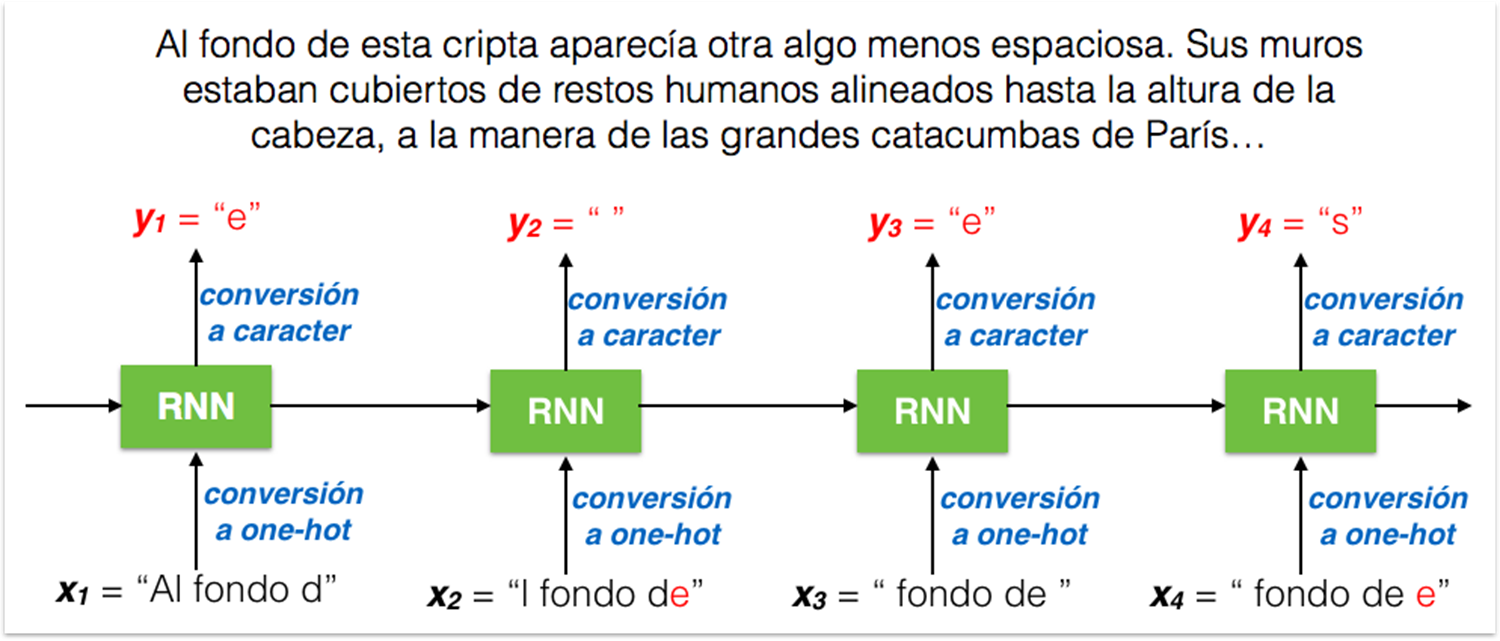



**EJEMPLO DE PRESENTACION DE DATOS A LA RED NEURONAL CON UNA SECUENCIA DE LONGITUD=10 PREDICIENDO LA SIGUIENTE PALABRA**


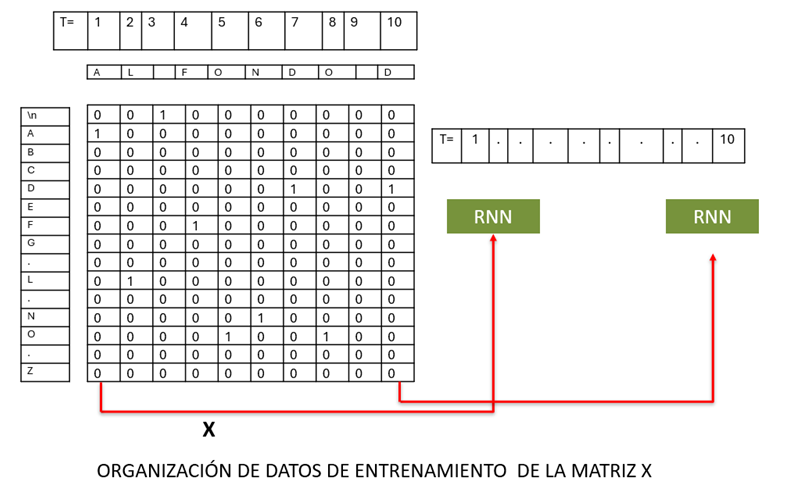


Cada uno de los vectores columna  correspondientes a
instantes de tiempos desde inicio T=1 hasta final T=10
pasaran y se guardara en la memoria del estado oculto
una vez la secuencia se complete se obtendra la salida y su correspondiente errores calculado.

El tamaño del Batchsizes correspondera al número de secuencias
que se computaran para obtener los errores de cada batch, para actualizar los pesos.

In [11]:
X

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False,  True, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False,  True, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False,  True, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [12]:
chars

['\n',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Estructura de la primera entrada X con 10 secuencias de letras a la RNN

In [13]:
print(X[0,:,:])
# Get the first sample from X
first_sample_one_hot = X[0, :, :]

# Convert the one-hot encoded data back to indices
# For each row (timestep), find the index where the value is True
indices = [np.argmax(row) for row in first_sample_one_hot]

# Convert the indices back to characters using the idx2char dictionary
characters = [idx2char[index] for index in indices]

# Join the characters to form the sequence
sequence = "".join(characters)

print("Original one-hot encoded data shape:", first_sample_one_hot.shape)
print("Indices:", indices)
print("Characters:", characters)
print("Reconstructed sequence:", sequence)

[[False False False False False False False False False False  True False
  False False False False False False False False False False False False
  False False False]
 [False False False False False False False False False False False False
  False False False False False False False False False  True False False
  False False False]
 [False  True False False False False False False False False False False
  False False False False False False False False False False False False
  False False False]
 [False False False False False False False False False False False False
  False False  True False False False False False False False False False
  False False False]
 [ True False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False]
 [False False False  True False False False False False False False False
  False False False False False False False False False False False False
  False

Estructura de la primera salida y que se le presenta al modelo de RNN  junto con la primera entrada X

In [14]:
print(y[0,:])
# Get the first sample from y (which is a single one-hot encoded vector)
first_label_one_hot = y[0, :]

# Find the index where the value is True
index = np.argmax(first_label_one_hot)

# Convert the index back to a character using the idx2char dictionary
character = idx2char[index]

print("Original one-hot encoded label shape:", first_label_one_hot.shape)
print("Index:", index)

[False False False False False False False False False False False False
 False False False  True False False False False False False False False
 False False False]
Original one-hot encoded label shape: (27,)
Index: 15


In [15]:
#Crear modelo SimpleRNN ---
model = Sequential([
    Input(shape=(SEQLEN, len(chars))),
    SimpleRNN(128,activation='tanh', return_sequences=True),
    SimpleRNN(64,activation='tanh'),
    Dense(len(chars), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Visualizamos la arquitectura del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 128)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,075 (133.11 KB)

 Trainable params: 34,075 (133.11 KB)

 Non-trainable params: 0 (0.00 B)

CREACION DEL MODELO RNN USANDO SIMPLE RNN

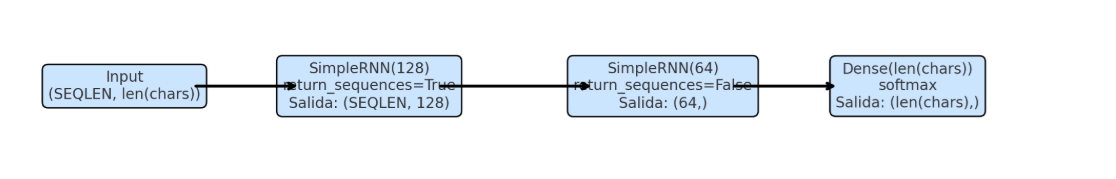



1.**Función de cada capa**

Input:
La entrada tiene forma (SEQLEN, len(chars)).
Esto significa que el modelo recibe una secuencia de longitud SEQLEN, donde cada elemento de la secuencia es un vector de tamaño len(chars) (por ejemplo, un one-hot de caracteres).

SimpleRNN(128, return_sequences=True):
Una RNN procesa la secuencia paso a paso.


Si return_sequences=False (por defecto), devuelve solo el último estado oculto, con tamaño (128,).


Si return_sequences=True, devuelve todos los estados ocultos de la secuencia, con tamaño (SEQLEN, 128).


SimpleRNN(64):
Recibe la salida de la primera RNN. En este caso no se usa return_sequences, por lo que solo devuelve el último estado oculto, con tamaño (64,).


Dense(len(chars), softmax):
Convierte el vector final en probabilidades sobre todos los posibles caracteres.


2. **Por qué return_sequences=True en la primera RNN?**


La razón es que la segunda RNN necesita como entrada una secuencia, no solo un vector.

Si la primera RNN devolviera únicamente el último estado (return_sequences=False), la segunda RNN recibiría un vector y no podría procesar la secuencia paso a paso.

Al usar return_sequences=True, la primera RNN entrega toda la secuencia de estados ocultos.

La segunda RNN toma esa secuencia y la resume en un único vector (al no tener return_sequences=True).

3. Resumen

return_sequences=True en la primera RNN permite que la salida sea una secuencia completa de estados ocultos, lo que hace posible que la segunda RNN siga procesando la información temporal.
Finalmente, la segunda RNN devuelve un único vector que luego se pasa a la capa Dense.

In [16]:
#Entrenar modelo ---
model.fit(X, y, batch_size=128, epochs=60)

Epoch 1/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.1519 - loss: 2.9285
Epoch 2/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3145 - loss: 2.4086
Epoch 3/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3636 - loss: 2.1627
Epoch 4/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4151 - loss: 1.9718
Epoch 5/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4605 - loss: 1.8605
Epoch 6/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 1.7149
Epoch 7/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5303 - loss: 1.6078
Epoch 8/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5522 - loss: 1.5379
Epoch 9/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5820 - loss: 1.4247
Epoch 10/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5799 - loss: 1.4240
Epoch 11/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6001 - loss: 1.3359
Epoch 12/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6202 - l

In [17]:
# --- Funciones de muestreo y generación ---
def sample(preds, temperature):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

def generar_nombre(model, temperature, seed=None, max_length=30 ):
    if seed is None:
        seed = random.choice(nombres).ljust(SEQLEN)[:SEQLEN]
    nombre = seed
    while True:
        x_pred = np.zeros((1, SEQLEN, len(chars)))
        for t, char in enumerate(seed):
            if char in char2idx:
                x_pred[0, t, char2idx[char]] = 1
        preds = model.predict(x_pred, verbose=0)[0]
        next_index = sample(preds, temperature)
        next_char = idx2char[next_index]
        if next_char == end_token or len(nombre) > max_length:
            break
        nombre += next_char
        seed = seed[1:] + next_char
    return nombre.replace('\n', '').strip()

### Generación de nombres

Vamos a crear una función gen que utilice tu modelo RNN entrenado para generar nombres, usando la capa recurrente (RNN) y la capa de salida (Dense + softmax). Como ya tienes el modelo entrenado y cargado, y el vocabulario listo (char2idx, idx2char), vamos a estructurarlo bien.



In [80]:
# --- Generación de nombres ---
print("\n--- Nombres generados ---")
for _ in range(100):
    print(generar_nombre(model, temperature=1))


--- Nombres generados ---
leon
fabian
andres
karen
emma
renata
david
santiago
paola
valentina
juan
alberto
gabriela
felix
luis
henry
juan
sebastian
tania
manuela
amalia
julian
wilson
lucia
felix
maria
elena
cindy
soledad
del
ana
sebastian
victoria
maria
alejandra
luis
leonardo
carlos
alejandro
tania
andres
nicolas
maria
esteban
maria
carlos
ana
diego
lourdes
sara
maria
carmen
martin
mauricio
natalia
santiago
ana
karen
carlos
raul
sofia
eduardo
diego
jose
cristian
emiliano
genesis
antonio
adela
ricardo
miguel
maria
maria
esteban
francisco
ana
elena
liliana
antonio
daniela
teresa
david
paola
maria
marco
juan
david
manuela
matias
katherine
elisa
alejandro
estefania
andres
susana
esteban
pablo
fernando
javier
gabriela


# <font color="green"> Ejemplo 2: Construcción de palabras en secuencia </font>

Fuente de texto: Alicia en el país de las maravillas

Objetivo: Entrenar una red neuronal recurrente (RNN) para generar texto similar al estilo del libro original, pero usando SimpleRNN, GRU y LSTM

## Lectura del Archivo:

Se obtiene el contenido del archivo de texto desde la URL proporcionada. El texto se normaliza eliminando espacios y convirtiendo a minúsculas.


In [19]:
import requests
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
# Descargar texto
url = "https://github.com/adiacla/RNN/raw/refs/heads/main/APMaravillas.txt"
response = requests.get(url)
assert response.status_code == 200, "No se pudo descargar el texto."
text = response.text.lower().strip()
print("Texto cargado con longitud:", len(text))
text[98:500]

Texto cargado con longitud: 160558


'escritor que fue, era matemático, dibujante, se le considera uno de los mejores fotógrafos de su tiempo y un poeta genial. era profesor en la universidad de oxford. allí conoció a la pequeña alicia, a quien durante un paseo por el bosque, empezó a contar una historia: las aventuras de alicia en el país de las maravillas, libro clave de la literatura no sólo infantil sino también para mayores, pues c'

## Procesamiento del Texto:

Se divide el texto en líneas y se eliminan las líneas vacías. Luego, todas las líneas se combinan en una sola cadena de texto.

In [21]:
#Tokenizar texto por palabras
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
encoded = tokenizer.texts_to_sequences([text])[0]
vocab_size = len(tokenizer.word_index) + 1
print("Tamaño del vocabulario:", vocab_size)

Tamaño del vocabulario: 4606


In [22]:
tokenizer.word_index

{'\r': 1,
 'de': 2,
 'la': 3,
 'que': 4,
 'y': 5,
 'el': 6,
 'a': 7,
 'en': 8,
 'se': 9,
 'no': 10,
 'alicia': 11,
 'un': 12,
 'con': 13,
 'lo': 14,
 'dijo': 15,
 'los': 16,
 'una': 17,
 'por': 18,
 'al': 19,
 'le': 20,
 'pero': 21,
 'del': 22,
 'es': 23,
 'su': 24,
 'para': 25,
 'las': 26,
 'había': 27,
 'me': 28,
 'si': 29,
 'más': 30,
 'muy': 31,
 'como': 32,
 'cuando': 33,
 'era': 34,
 'todo': 35,
 'sus': 36,
 'reina': 37,
 'mientras': 38,
 'estaba': 39,
 'nada': 40,
 'sin': 41,
 'yo': 42,
 'tan': 43,
 'qué': 44,
 'ella': 45,
 'pues': 46,
 'rey': 47,
 'ahora': 48,
 'tortuga': 49,
 'vez': 50,
 'voz': 51,
 'o': 52,
 'este': 53,
 '»': 54,
 'cabeza': 55,
 'porque': 56,
 'esto': 57,
 'todos': 58,
 'preguntó': 59,
 'sombrerero': 60,
 'sí': 61,
 'conejo': 62,
 'ya': 63,
 'grifo': 64,
 'falsa': 65,
 'así': 66,
 'dos': 67,
 'empezó': 68,
 'decir': 69,
 'esta': 70,
 'hasta': 71,
 'ni': 72,
 'duquesa': 73,
 'después': 74,
 'siguió': 75,
 'tiempo': 76,
 'te': 77,
 'pensó': 78,
 'ratón': 79,
 '

In [23]:
encoded

[1262,
 956,
 1984,
 1985,
 1,
 11,
 8,
 6,
 1986,
 2,
 26,
 1263,
 1,
 1262,
 956,
 477,
 22,
 93,
 1987,
 4,
 107,
 34,
 1988,
 1989,
 9,
 20,
 1264,
 94,
 2,
 16,
 1990,
 1991,
 2,
 24,
 76,
 5,
 12,
 1992,
 1993,
 34,
 1265,
 8,
 3,
 1994,
 2,
 1995,
 84,
 1996,
 7,
 3,
 331,
 11,
 7,
 767,
 232,
 12,
 1266,
 18,
 6,
 332,
 68,
 7,
 957,
 17,
 152,
 26,
 422,
 2,
 11,
 8,
 6,
 668,
 2,
 26,
 768,
 372,
 1997,
 2,
 3,
 1998,
 10,
 120,
 1267,
 958,
 153,
 25,
 1999,
 46,
 956,
 206,
 4,
 25,
 423,
 8,
 6,
 2000,
 2,
 3,
 2001,
 5,
 6,
 2002,
 10,
 769,
 2003,
 2,
 2004,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2005,
 1,
 1,
 8,
 3,
 558,
 22,
 62,
 1,
 6,
 333,
 2,
 2006,
 1,
 17,
 373,
 265,
 5,
 17,
 374,
 152,
 1,
 3,
 127,
 22,
 62,
 1,
 959,
 2,
 17,
 114,
 1,
 1268,
 5,
 334,
 1,
 17,
 559,
 2,
 669,
 1,
 6,
 287,
 2,
 3,
 37,
 1,
 3,
 152,
 2,
 3,
 65,
 49,
 1,
 6,
 288,
 2,
 3,
 424,
 1,
 1269,
 1270,
 26,
 560,
 1,
 3,
 960,
 2,
 11,
 1,
 1,
 1,
 1,
 7,
 961,
 2,
 3,
 335,
 1271,
 2,
 

In [24]:
# Parámetros
SEQLEN = 40 # Longitud de la secuencia de entrada
STEP = 1    # Desplazamiento para crear la siguiente secuencia

# Crear secuencias y etiquetas
X = [] # Lista para almacenar las secuencias de entrada (los "contextos")
Y = [] # Lista para almacenar las etiquetas de salida (la siguiente palabra a predecir)

# Itera sobre la lista de palabras codificadas ('encoded')
# El rango va desde el inicio hasta casi el final, dejando espacio para la secuencia de longitud SEQLEN y la siguiente palabra
for i in range(0, len(encoded) - SEQLEN, STEP):
    # Toma una secuencia de palabras codificadas desde la posición 'i' hasta 'i + SEQLEN'
    X.append(encoded[i:i+SEQLEN])
    # Toma la palabra codificada que sigue inmediatamente a la secuencia anterior (en la posición 'i + SEQLEN')
    Y.append(encoded[i+SEQLEN])

# Convierte las listas de secuencias y etiquetas a arrays de NumPy
X = np.array(X)
# Convierte las etiquetas de salida (Y) a formato one-hot encoding
# num_classes es el tamaño total del vocabulario
Y = to_categorical(Y, num_classes=vocab_size)

# Imprime las dimensiones (shapes) de las matrices X y Y resultantes
print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (29097, 40)
Shape de Y: (29097, 4606)


In [25]:
print(X[1,:])

[ 956 1984 1985    1   11    8    6 1986    2   26 1263    1 1262  956
  477   22   93 1987    4  107   34 1988 1989    9   20 1264   94    2
   16 1990 1991    2   24   76    5   12 1992 1993   34 1265]


## Construcción del Modelo:

Se crea un modelo secuencial con una capa SimpleRNN que toma las entradas y devuelve la probabilidad de los siguientes caracteres. La salida pasa a través de una capa densa con activación softmax.

In [26]:
#SimpleRN
from keras.models import Sequential
from keras.layers import Dense, Activation, SimpleRNN, GRU, LSTM, Input

# Modelo secuencial con Embedding + RNN
HIDDEN_SIZE = 128

modelSimple = Sequential()
modelSimple.add(Embedding(input_dim=vocab_size, output_dim=100))
modelSimple.add(SimpleRNN(HIDDEN_SIZE, unroll=True))
modelSimple.add(Dense(vocab_size, activation='softmax'))

modelSimple.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])


In [27]:
modelSimple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Modelo:

El modelo se entrena varias veces (definido por NUM_ITERATIONS), lo que permite que aprenda mejor las relaciones en los datos.

En cada iteración, el modelo se ajusta a los datos de entrada X y las etiquetas y durante un número específico de épocas (NUM_EPOCHS_PER_ITERATION).



In [28]:
# Entrenar y guardar el historial
history = modelSimple.fit(X, Y, batch_size=128, epochs=50)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.0378 - loss: 6.9085
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0503 - loss: 6.4409
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0697 - loss: 6.0983
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0829 - loss: 5.9251
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0998 - loss: 5.7737
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1134 - loss: 5.5727
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1244 - loss: 5.4167
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1346 - loss: 5.3083
Epoch 9/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1487 - loss: 5.1702
Epoch 10/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1590 - loss: 5.0890
Epoch 11/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1635 - loss: 4.9783
Epoch 12/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

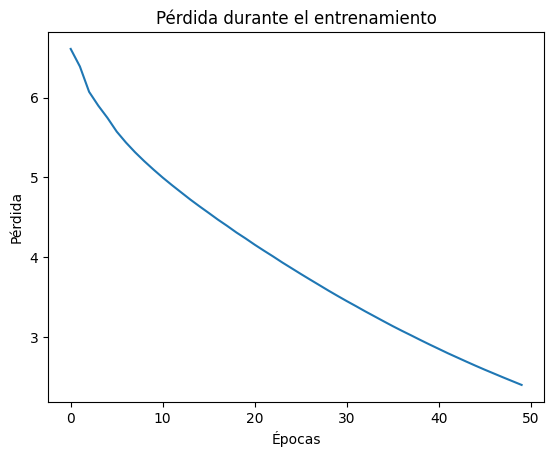

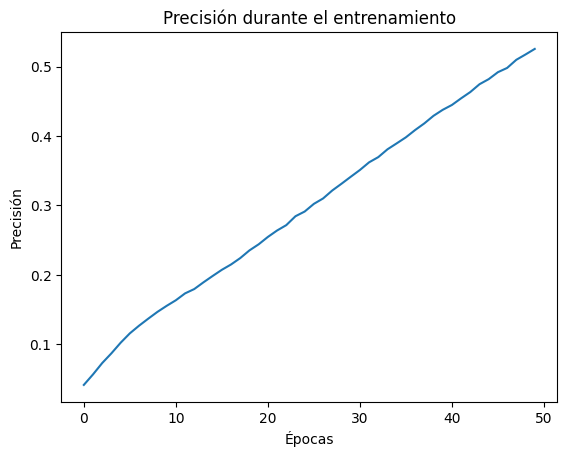

In [29]:
# Acceder a la pérdida y precisión durante el entrenamiento
import matplotlib.pyplot as plt

# Graficar la pérdida
plt.plot(history.history['loss'])
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.show()

# Graficar la precisión (si se utilizó 'accuracy' como métrica)
plt.plot(history.history['accuracy'])
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.show()

#Función de temperatura


```python
TEMPERATURE = 0.5  # Muy predecible, conservador
TEMPERATURE = 1.0  # Equilibrado
TEMPERATURE = 1.5  # Más loco y creativo```



## Generación de texto:

Al final de todas las iteraciones, se imprime una nueva línea para mejorar la legibilidad de la salida.
Este código te permite entrenar un modelo de generación de texto en español utilizando una red neuronal recurrente.

In [30]:
# Función para predecir texto (palabras)

def predecir_texto(model, seed, num_words, tokenizer, temperature):
    generated = seed
    test_words = seed.split()  # Convertir la semilla en una lista de palabras

    for _ in range(num_words):
        # Convertir palabras a índices
        encoded = tokenizer.texts_to_sequences([' '.join(test_words)])[0]

        # Aplicar padding al tamaño SEQLEN
        X_test = pad_sequences([encoded], maxlen=SEQLEN)

        # Predecir la siguiente palabra
        pred = model.predict(X_test, verbose=0)[0]
        next_index = sample_with_temperature(pred, temperature)

        # Obtener la palabra a partir del índice
        next_word = tokenizer.index_word.get(next_index, '')  # Evitar errores si el índice no existe

        # Añadir la palabra al texto generado
        generated += " " + next_word

        # Actualizar la lista de palabras para la siguiente iteración
        test_words.append(next_word)

    return generated

# Función para aplicar la temperatura y muestrear
def sample_with_temperature(preds, temperature):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)


La función sample_with_temperature toma las probabilidades que tu modelo RNN predice para la siguiente palabra y las ajusta usando la temperature. Este ajuste influye en cómo de "sorprendente" o "predecible" será la siguiente palabra elegida.

preds: Son las probabilidades de que cada palabra en tu vocabulario sea la siguiente palabra. Estas son las salidas directas de la capa softmax de tu modelo. Por ejemplo, si tu vocabulario tiene 1000 palabras, preds será un array de 1000 números, donde cada número es la probabilidad de una palabra específica.

np.log(preds + 1e-8): Se calcula el logaritmo de estas probabilidades. Esto convierte los valores de probabilidad (que están entre 0 y 1) en números negativos (excepto si la probabilidad es 1). El pequeño 1e-8 se añade para evitar tomar el logaritmo de cero, lo que causaría un error.

... / temperature: Aquí es donde la temperatura entra en juego. Se dividen los logaritmos de las probabilidades entre la temperatura.

Si temperature es alta (por ejemplo, > 1.0): La división por un número grande hace que los valores resultantes (preds) sean más cercanos entre sí. Las diferencias entre las probabilidades de las palabras más probables y las menos probables se reducen.

Si temperature es baja (por ejemplo, < 1.0): La división por un número pequeño hace que los valores resultantes (preds) sean más extremos. Las diferencias entre las probabilidades de las palabras más probables y las menos probables se amplifican.


Si temperature es 1.0: No hay cambio en los logaritmos de las probabilidades originales.


**EN RESUMEN**: La temperatura "suaviza" o "agudiza" la distribución de probabilidades de la siguiente palabra que predice el modelo.
•	Temperatura alta: Aumenta la probabilidad de elegir palabras que el modelo consideraba menos probables. Esto hace que el texto generado sea más aleatorio, diverso y potencialmente creativo o disparatado.
•	Temperatura baja: Disminuye la probabilidad de elegir palabras que el modelo consideraba menos probables, favoreciendo fuertemente a las palabras más probables. Esto hace que el texto generado sea más predecible, conservador y similar a los datos de entrenamiento, pero también menos propenso a errores o incoherencias inesperadas.
Es un parámetro que te permite controlar el grado de exploración o explotación de las probabilidades predichas por el modelo durante la generación de texto.


In [31]:
# Semilla inicial (puede ser cualquier frase de inicio)
seed_text = "alicia estaba"

# Número de palabras a generar
num_words_to_generate = 100

# Llamar a la función de predicción
generated_text = predecir_texto(modelSimple, seed_text, num_words_to_generate, tokenizer, temperature=0.7)

# Mostrar el texto generado
print(generated_text)


 ¿qué ahora podría ya hacer un poco más dijo el rey por


In [32]:
# Probar la generación con distintas temperaturas
seed = text[2400:2400 + SEQLEN]  # Esto debe ser una cadena de palabras
print("Seed:", seed)

# Asegurarse de que la semilla esté en formato de palabras
seed_words = seed.split()  # Dividir la semilla en palabras

# Probar con distintas temperaturas
for temp in [0.5, 1.0, 1.5]:
    print(f"\nTemperatura: {temp}")
    # Llamar a la función para generar texto con palabras
    generated_text = predecir_texto(modelSimple, " ".join(seed_words), num_words=400, tokenizer=tokenizer, temperature=temp)
    print(generated_text)


Seed: 

alicia, para tí este cuento infantil

Temperatura: 0.5
 después después la falsa tortuga con un

Temperatura: 1.0
 y que

Temperatura: 1.5
 lloriqueando haber muchos valla bajó sucede muy jurado empezaron además sesos debía tener quejumbrosa su desconcertante pataleando confesó sirva de costaba ¿de chaleco jarro de


**Por que se observa que al aumentar la temperatura no hay aparentemente mas palabras?**


**Muestreo de Índices Poco Frecuentes a Temperaturas Altas**: A temperaturas muy altas (1.0, 1.5), la distribución de probabilidades se vuelve casi uniforme, dando a casi todos los índices del vocabulario una oportunidad significativa de ser seleccionados. Esto significa que podrías estar muestreando índices que corresponden a:
Palabras muy raras o inexistentes: El tokenizer.index_word.get(next_index, '') tiene un valor por defecto de '' (cadena vacía) si el índice no se encuentra en el diccionario index_word. Si se muestrean índices inválidos o que no tienen una palabra asociada, se añadirá una cadena vacía ("") seguida de un espacio, lo que hará que la generación parezca "truncada" o llena de espacios.

**Por que parece que aunque se tenga una temperatura pequeña el texto generado le falta conexion o sentido?**


Como se observa el modelo RNN tiene inconvenientes en la construcción de frases completas con sentido y relación entre palabras seguidas, esto ocurre bien por underfitting ( mejorar la arquitectura de red, Learning rate,  # de Epochs) ó por el desvanecimiento del gradiente (vanishing gradient) es un fenómeno común en redes neuronales profundas, especialmente en modelos recurrentes como el SimpleRNN. Este problema puede tener efectos negativos en el proceso de entrenamiento, dificultando que el modelo aprenda relaciones a largo plazo en secuencias de datos, como texto o series temporales.


# El Problema del Gradiente Desvanecido

El desvanecimiento del gradiente ocurre cuando los gradientes (derivadas parciales de la función de pérdida con respecto a los parámetros del modelo) se vuelven extremadamente pequeños durante el proceso de retropropagación. Esto puede hacer que las actualizaciones de los pesos sean muy pequeñas, lo que ralentiza o incluso detiene el aprendizaje.

En una red neuronal recurrente como SimpleRNN, el problema se amplifica debido a las conexiones recurrentes, donde la información se "pasa" de un paso de tiempo a otro. Los gradientes que se calculan en cada paso hacia atrás pueden disminuir exponencialmente a medida que se retropropagan a través de muchos pasos de tiempo.

## Efectos del desvanecimiento del gradiente en un modelo SimpleRNN:

**Dificultad para aprender dependencias a largo plazo:**

* El SimpleRNN tiene una estructura que hace que los gradientes se desvanecen rápidamente, especialmente si hay muchas capas o pasos de tiempo en la secuencia.

* Esto impide que el modelo aprenda patrones o dependencias que ocurren a largo plazo (por ejemplo, relaciones entre palabras o eventos distantes en el tiempo).

**Entrenamiento lento o estancado:**

* Debido al desvanecimiento del gradiente, el modelo puede experimentar lentitud en el entrenamiento, ya que las actualizaciones de los pesos se hacen muy pequeñas y los pesos no cambian de manera significativa.

* Esto puede llevar a que el modelo se quede atrapado en un mínimo local o simplemente no converja correctamente durante el entrenamiento.

**Desempeño deteriorado:**

* Los modelos con desvanecimiento de gradiente tienden a no generalizar bien, ya que no pueden capturar patrones complejos o dependencias a largo plazo.

* El modelo tiende a predecir de manera mediocre o incluso de manera completamente incorrecta, especialmente en tareas de predicción de secuencias largas o complejas.


<img src="https://github.com/adiacla/RNN/blob/main/desv_gradiente.jpg?raw=true">


## Soluciones al desvanecimiento del gradiente:
Para mitigar el problema del desvanecimiento del gradiente en redes neuronales recurrentes, hay varias estrategias y soluciones que se pueden aplicar:

**Usar LSTM o GRU en lugar de SimpleRNN:**

LSTM (Long Short-Term Memory) y GRU (Gated Recurrent Unit) son variantes de las redes neuronales recurrentes diseñadas específicamente para manejar el problema del desvanecimiento del gradiente. Estas arquitecturas tienen puertas que permiten que las redes recuerden información durante períodos de tiempo más largos sin que los gradientes se desvanezcan.

Las LSTM y GRU son más eficientes para capturar dependencias a largo plazo en secuencias de datos, ya que tienen mecanismos internos que controlan cómo se mantiene y actualiza la memoria a lo largo del tiempo.

**Inicialización adecuada de los pesos:**

Una buena inicialización de los pesos (por ejemplo, usando He initialization o Xavier initialization) puede ayudar a reducir el riesgo de desvanecimiento del gradiente, al asegurar que los gradientes no se vuelvan demasiado pequeños desde el principio.

**Uso de funciones de activación diferentes:**

La función sigmoide y la tangente hiperbólica (tanh) pueden contribuir al desvanecimiento del gradiente. Usar activaciones como ReLU (Rectified Linear Unit) en las capas recurrentes puede ayudar a mitigar este problema, ya que no tienen saturación en la parte positiva, lo que mantiene los gradientes más grandes y estables.

**Técnicas de normalización:**

La normalización de lotes (Batch Normalization) y la normalización de gradientes pueden ayudar a evitar que los gradientes se desvanezcan, aunque estas técnicas son más comunes en redes neuronales tradicionales, no siempre son aplicables directamente a las RNN debido a la naturaleza secuencial de los datos.

**Recorte de gradientes (Gradient Clipping):**

El recorte de gradientes es una técnica en la que se limita el valor de los gradientes si exceden un cierto umbral. Esto no elimina el desvanecimiento del gradiente, pero ayuda a evitar problemas de explosión del gradiente, otro problema relacionado que puede ocurrir en redes profundas.

## <font color="blue">Construcción del Modelo con GRU: </font>

Se crea un modelo secuencial con una capa GRU que toma las entradas y devuelve la probabilidad de los siguientes caracteres. La salida pasa a través de una capa densa con activación softmax.

In [33]:
SEQLEN = 50   # O incluso más
EPOCHS = 50
OPTIMIZER = 'adam'

In [34]:
HIDDEN_SIZE

128

In [35]:
#Gru model
modelGRU = Sequential()
modelGRU.add(Embedding(input_dim=vocab_size, output_dim=100))
modelGRU.add(GRU(HIDDEN_SIZE, return_sequences=True))  # <- Esto es clave  (Puede probar solo con una GRU)
modelGRU.add(GRU(HIDDEN_SIZE))                         # <- Aquí sí puede ser False (por defecto lo es)
modelGRU.add(Dense(vocab_size, activation='softmax'))

modelGRU.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [36]:
modelGRU.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Entrenar
history = modelGRU.fit(X, Y, batch_size=128, epochs=50)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.0415 - loss: 7.1542
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0426 - loss: 6.4500
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0454 - loss: 6.4111
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0621 - loss: 6.1938
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0679 - loss: 5.9580
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0808 - loss: 5.7999
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0886 - loss: 5.5762
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1054 - loss: 5.3470
Epoch 9/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1253 - loss: 5.1278
Epoch 10/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1334 - loss: 4.9033
Epoch 11/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1555 - loss: 4.7051
Epoch 12/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 

Vamos a ver cómo se mejora el resultado


In [38]:
# Semilla inicial (puede ser cualquier frase de inicio)
seed_text = "alicia estaba empezando"

# Número de palabras a generar
num_words_to_generate = 200

# Llamar a la función de predicción
generated_text = predecir_texto(modelGRU, seed_text, num_words_to_generate, tokenizer, temperature=0.8)

# Mostrar el texto generado
print(generated_text)


 ¡qué lacayo sería tal pregunta tiene así es todas las injusticias del conejo


In [39]:
# Probar la generación con distintas temperaturas
seed = text[2400:2400 + SEQLEN]  # Esto debe ser una cadena de palabras
print("Seed:", seed)

# Asegurarse de que la semilla esté en formato de palabras
seed_words = seed.split()  # Dividir la semilla en palabras

# Probar con distintas temperaturas
for temp in [0.5, 1, 1.5]:
    print(f"\nTemperatura: {temp}")
    # Llamar a la función para generar texto con palabras
    generated_text = predecir_texto(modelGRU, " ".join(seed_words), num_words=400, tokenizer=tokenizer, temperature=temp)
    print(generated_text)


Seed: 

alicia, para tí este cuento infantil.
ponlo c

Temperatura: 0.5
 alicia pensó que yo le gusta nada de nada ni

Temperatura: 1
 todo lo que yo no

Temperatura: 1.5
 el ratón frunciendo el gato ¡y más de otros siquiera no tuvo la vaga mala dimisión de ojillos ya estaba si son además entender preguntó ¿qué al día del ratón dio la duquesa hacia alicia empieza tengo pero ¿es que se mío observando a es mucha cinturón y estantes tendría dices más será que todo volvió por ir durante unos minutos aquí 


Aqui el modelo aprendio con mayor memoria y  con temperaturas mas altas el texto puede ser ""mas loco"" debido a la escogencia de palabras menos probables en la secuencia, en cambio con una temperatura baja hace que el modelo se incline mucho más a elegir la palabra (o carácter) que tiene la probabilidad más alta según su predicción. La distribución de probabilidades se vuelve muy "puntiaguda" alrededor de la opción más probable.
¿Qué significa esto en la práctica?

1.	Mayor predictibilidad y repetición: El modelo tiende a seguir los patrones más fuertes y comunes en los datos de entrenamiento. Si en el conjunto de datos hay frases o secuencias que aparecen con mucha frecuencia, el modelo con baja temperatura será muy propenso a generarlas una y otra vez.

2.	Riesgo de ciclos o estancamiento: En algunos casos, el modelo puede caer en un ciclo repetitivo de palabras o frases muy probables. Por ejemplo, podría generar "la casa la casa la casa..." si "la casa" es una secuencia muy probable después de ciertas palabras.

3.	Finalización prematura: En el primer ejemplo que vimos (generación de caracteres para nombres), el carácter de fin de nombre es \n. Si en algún punto del proceso de generación, el carácter \n tiene una probabilidad significativamente alta (quizás porque es el carácter más común después de ciertas secuencias cortas), y usas una temperatura baja, el modelo

## <font color="blue">Memoria a Largo y Corto Plazo (Long/Short Term Memory LSTM) </font>

##Arquitecturas Básica  RNN

Los módulos de repetición RNN sencillos tienen una estructura básica con una capa tanh única. La estructura sencilla de la RNN adolece de memoria corta, por lo que le cuesta retener la información de pasos temporales anteriores en datos secuenciales más numerosos.


![](https://miro.medium.com/v2/resize:fit:1170/1*tvIjQjHW-1WGECloYD5efQ.png)

![](https://media.springernature.com/lw685/springer-static/image/art%3A10.1007%2Fs44196-023-00374-8/MediaObjects/44196_2023_374_Fig3_HTML.png?as=webp)

La Long short-term memory (LSTM) es el tipo avanzado de RNN, que se diseñó para evitar tanto los problemas de desvanecimiento como los de explosión de gradiente. Al igual que la RNN, la LSTM tiene módulos que se repiten, pero la estructura es diferente.

En lugar de tener una capa única de tanh, la LSTM tiene cuatro capas que interactúan y se comunican. Esta estructura de cuatro capas ayuda a la LSTM a conservar la memoria a largo plazo y puede utilizarse en varios problemas secuenciales, como la traducción automática, la síntesis del habla, el reconocimiento del habla y el reconocimiento de la escritura a mano. Puedes adquirir experiencia práctica en LSTM siguiendo la guía: LSTM Python para predicciones bursátiles.

Cada una de las tres puertas (entrada, salida y olvido) puede entenderse como una "neurona" artificial convencional, como en una red neuronal multicapa o de propagación hacia adelante (feedforward): es decir, calculan una activación (mediante una función de activación) de una suma ponderada. Intuitivamente, pueden considerarse como reguladores del flujo de valores que atraviesan las conexiones de la LSTM; de ahí la denominación de "puerta". Existen conexiones entre estas puertas y la celda.

La expresión "memoria a largo y corto plazo" se refiere a que LSTM es un modelo para la memoria de corto plazo que puede durar un largo periodo de tiempo. Las LSTM son ideales para clasificar, procesar y predecir series temporales cuando existen desfases temporales de tamaño y duración desconocidos entre eventos importantes. Las LSTM fueron desarrolladas para lidiar con el problema del gradiente desvanecido y el problema del gradiente explosivo al entrenar redes neuronales recurrentes tradicionales.


![adiaz](https://github.com/adiacla/bigdata/blob/master/lstm.JPG?raw=true)



Referencias:

Deep NLP: Redes LSTM (Memoria a Largo y Corto Plazo) con Matemáticas - Medium
[link text](https://https://medium.com/deep-math-machine-learning-ai/chapter-10-1-deepnlp-lstm-long-short-term-memory-networks-with-math-21477f8e4235)



##Componentes de una celda LSTM

La celda LSTM contiene los siguientes componentes:

![imagen](https://abdatum.com/media/images/lstm-estructura.jpeg)

**Puerta de olvido (f):**
Una red neuronal con activación sigmoide que decide qué parte de la información del estado de memoria anterior debe ser descartada.

**Puerta de entrada (i):**
Una red neuronal con activación sigmoide que determina cuánta información nueva se incorporará al estado de memoria.

**Capa candidata (C̃):**
Una red neuronal con activación tanh que genera nuevos valores candidatos para actualizar el estado de memoria.

**Actualización del estado de memoria (C):**
Se calcula combinando la información retenida (tras pasar por la puerta de olvido) con los nuevos valores candidatos ponderados por la puerta de entrada.

**Puerta de salida (o):**
Una red neuronal con activación sigmoide que controla qué parte del estado de memoria se usará para calcular el estado oculto.

**Estado oculto (h):**
El vector de salida en el paso de tiempo actual, calculado a partir del estado de memoria actualizado y filtrado por la puerta de salida.


###**Entradas de la celda LSTM en cada paso:**

𝑋𝑡: entrada actual

𝐻𝑡−1: estado oculto anterior


𝐶𝑡−1: estado de memoria anterior
Salidas de la celda LSTM:

𝐻𝑡: estado oculto actual

𝐶𝑡: estado de memoria actual

Estos componentes trabajan juntos para permitir que la LSTM retenga información relevante a lo largo de pasos de tiempo y olvide aquella que no es útil, facilitando el manejo de dependencias a largo plazo en las secuencias de datos.

## Funcionamiento de las Puertas en una Celda LSTM

**Puerta de Olvido (f):**
Primero, la celda LSTM toma el estado de memoria anterior
𝐶𝑡−1 y lo multiplica, elemento a elemento, por el valor de la puerta de olvido (f) para decidir el estado de memoria actual
𝐶𝑡. La puerta de olvido tiene valores entre 0 y 1:
Si el valor de la puerta de olvido es 0, el estado de memoria anterior se olvida completamente.
Si el valor de la puerta de olvido es 1, el estado de memoria anterior se conserva por completo en la celda.
Esto permite que la celda decida cuánta información del pasado debe mantener o descartar.




**C<sub>t</sub> = C<sub>t-1</sub> * f<sub>t</sub>**

Cálculo del Nuevo Estado de Memoria:

**C<sub>t</sub> = C<sub>t</sub> + (I<sub>t</sub> * C\`<sub>t</sub>)**


Ahora, calculamos la salida:

**H<sub>t</sub> = tanh(C<sub>t</sub>)**




In [40]:
from keras.layers import Embedding, LSTM, Dropout, Dense
#LSTM

# Parámetros
HIDDEN_SIZE = 128
EMBED_DIM = 100

# Definir el modelo LSTM
modeloLSTM = Sequential()
modeloLSTM.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM))
modeloLSTM.add(LSTM(HIDDEN_SIZE, return_sequences=True, unroll=True))
modeloLSTM.add(LSTM(HIDDEN_SIZE))
modeloLSTM.add(Dropout(0.2))  # Dropout después de la segunda LSTM  para evitar sobreentrenamiento
modeloLSTM.add(Dense(vocab_size, activation='softmax'))

modeloLSTM.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

#Para sintonizar Learning Rate

#from keras.optimizers import RMSprop
#learning_rate=0.0023

#optimizer = RMSprop(learning_rate=learning_rate)
#modeloLSTM.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])




In [41]:
modeloLSTM.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Entrenar el modelo LSTM
historyLSTM = modeloLSTM.fit(X, Y, batch_size=128, epochs=50)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.0414 - loss: 7.0482
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0419 - loss: 6.4174
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0430 - loss: 6.4128
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0469 - loss: 6.4183
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0434 - loss: 6.4309
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0448 - loss: 6.3745
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0474 - loss: 6.2912
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0550 - loss: 6.1641
Epoch 9/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0608 - loss: 6.0806
Epoch 10/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0650 - loss: 6.0446
Epoch 11/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0666 - loss: 5.9741
Epoch 12/50
228/228 ━━━━━━━━━━━━━━━━━━━━

In [43]:
seed_text = "alicia estaba empezando"
num_words_to_generate = 400

generated_text = predecir_texto(modeloLSTM, seed_text, num_words_to_generate, tokenizer, temperature=0.7)
print(generated_text)


 alicia dijo alicia se levantó en el pez y se miró de sopa que estar tema de el ratón era un impresionada un estrofas o un molestarse ahí y allí había «y a esta lado la cabeza se dijo el sombrerero y la cabeza de dos arregló al conejo blanco de la duquesa los ojos y muy probar en la parte y se mía pero por su dilema después de la cocinera se cerca de lo que las cantara un codo de la cabeza pero se siempre muy definitiva en sus granizada de veces no ir a correr a


In [44]:
# Probar la generación con distintas temperaturas
seed = text[2400:2400 + SEQLEN]  # Esto debe ser una cadena de palabras
print("Seed:", seed)

# Asegurarse de que la semilla esté en formato de palabras
seed_words = seed.split()  # Dividir la semilla en palabras

# Probar con distintas temperaturas
for temp in [0.5, 0.8, 1.2]:
    print(f"\nTemperatura: {temp}")
    # Llamar a la función para generar texto con palabras
    generated_text = predecir_texto(modelGRU, " ".join(seed_words), num_words=400, tokenizer=tokenizer, temperature=temp)
    print(generated_text)


Seed: 

alicia, para tí este cuento infantil.
ponlo c

Temperatura: 0.5
 capítulo horas contestar a esta parte del mar se dijo alicia lo he leído del tiempo para no me equivoco he acuerdo dijo

Temperatura: 0.8
 ¿pero me pregunto una gran

Temperatura: 1.2
 había exactamente un gran baile de persona que mis oigan de sacarse de tortuga


# <font color="green">Ejercicio con Serie de tiempo para precio de las acciones
Modelo de predicción de precios de acciones utilizando una red neuronal recurrente (RNN), específicamente una LSTM (Long Short-Term Memory). }

Este modelo tiene como objetivo predecir el precio de las acciones de Tesla basándose en datos históricos.

 A continuación explico paso a paso qué hace cada parte del código:

In [45]:
! pip list | grep "yfinance"

#!pip install yfinance

yfinance                                 0.2.66


# 1. Importación de bibliotecas:
Se importan varias bibliotecas esenciales para el procesamiento de datos (numpy, pandas), gráficos (matplotlib, plotly), preprocesamiento de datos (MinMaxScaler de sklearn), y para la creación y entrenamiento del modelo (keras).



In [46]:
# Importando las bibliotecas
import numpy as np  # Para operaciones matemáticas y manejo de arrays.
import matplotlib.pyplot as plt  # Para crear gráficos.
plt.style.use('fivethirtyeight')  # Estilo visual de los gráficos (estilo FiveThirtyEight).
import pandas as pd  # Para manejo de datos en formato tabular (dataframes).
from sklearn.preprocessing import MinMaxScaler  # Para normalizar los datos.
from keras.models import Sequential  # Para construir modelos secuenciales.
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional  # Para añadir capas al modelo.
from keras.optimizers import SGD  # Para usar el optimizador Stochastic Gradient Descent.
import math  # Para operaciones matemáticas adicionales.
from sklearn.metrics import mean_squared_error  # Para calcular el error cuadrático medio (MSE).


In [47]:
# Algunas funciones para ayudar
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real TeslaStock Price')  # Grafica los precios reales en rojo.
    plt.plot(predicted, color='blue', label='Predicted Tesla Stock Price')  # Grafica los precios predichos en azul.
    plt.title('Tesla Stock Price Prediction')  # Título del gráfico.
    plt.xlabel('Tiempo-fecha')  # Etiqueta del eje X (Tiempo).
    plt.ylabel('Tesla Stock Price')  # Etiqueta del eje Y (Precio de las acciones de IBM).
    plt.legend()  # Muestra la leyenda para identificar las líneas.
    plt.show()  # Muestra el gráfico.

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))  # Calcula la raíz cuadrada del error cuadrático medio (RMSE).
    print("Raiz cuadra del error {}.".format(rmse))  # Imprime el valor del RMSE.



# 2. Descarga de los datos históricos de Tesla:
Utiliza la API de Yahoo Finance (yfinance) para descargar los precios históricos de las acciones de Tesla desde enero de 2023 hasta la fecha actual (noviembre de 2024).
Los datos descargados incluyen precios de apertura, cierre, máximo, mínimo, volumen de transacciones, etc. Se guarda en un DataFrame de pandas.

(https://finance.yahoo.com/quote/TSLA/)


In [48]:
import yfinance as yf

# Descargar los datos históricos de las acciones de Tesla
tesla = yf.Ticker('TSLA')

# Obtener los precios históricos para el periodo desde 2023 hasta la fecha actual
dataset = tesla.history(start="2023-01-01")  # Ajustar la fecha de fin a la actual


dataset


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-03 00:00:00-05:00,118.470001,118.800003,104.639999,108.099998,231402800,0.0,0.0
2023-01-04 00:00:00-05:00,109.110001,114.589996,107.519997,113.639999,180389000,0.0,0.0
2023-01-05 00:00:00-05:00,110.510002,111.750000,107.160004,110.339996,157986300,0.0,0.0
2023-01-06 00:00:00-05:00,103.000000,114.389999,101.809998,113.059998,220911100,0.0,0.0
2023-01-09 00:00:00-05:00,118.959999,123.519997,117.110001,119.769997,190284000,0.0,0.0
...,...,...,...,...,...,...,...
2025-11-03 00:00:00-05:00,455.989990,474.070007,453.799988,468.369995,84595200,0.0,0.0
2025-11-04 00:00:00-05:00,454.459991,460.220001,443.600006,444.260010,87756600,0.0,0.0
2025-11-05 00:00:00-05:00,452.049988,466.329987,440.709991,462.070007,85573000,0.0,0.0


In [49]:

# También puedes guardar los datos en un archivo CSV si lo deseas
dataset.to_csv('tesla_stock_data.csv')

In [50]:

dataset.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-03 00:00:00-05:00,118.470001,118.800003,104.639999,108.099998,231402800,0.0,0.0
2023-01-04 00:00:00-05:00,109.110001,114.589996,107.519997,113.639999,180389000,0.0,0.0
2023-01-05 00:00:00-05:00,110.510002,111.750000,107.160004,110.339996,157986300,0.0,0.0
2023-01-06 00:00:00-05:00,103.000000,114.389999,101.809998,113.059998,220911100,0.0,0.0
2023-01-09 00:00:00-05:00,118.959999,123.519997,117.110001,119.769997,190284000,0.0,0.0


In [51]:
dataset[:'2024']

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-03 00:00:00-05:00,118.470001,118.800003,104.639999,108.099998,231402800,0.0,0.0
2023-01-04 00:00:00-05:00,109.110001,114.589996,107.519997,113.639999,180389000,0.0,0.0
2023-01-05 00:00:00-05:00,110.510002,111.750000,107.160004,110.339996,157986300,0.0,0.0
2023-01-06 00:00:00-05:00,103.000000,114.389999,101.809998,113.059998,220911100,0.0,0.0
2023-01-09 00:00:00-05:00,118.959999,123.519997,117.110001,119.769997,190284000,0.0,0.0
...,...,...,...,...,...,...,...
2024-12-24 00:00:00-05:00,435.899994,462.779999,435.140015,462.279999,59551800,0.0,0.0
2024-12-26 00:00:00-05:00,465.160004,465.329987,451.019989,454.130005,76366400,0.0,0.0
2024-12-27 00:00:00-05:00,449.519989,450.000000,426.500000,431.660004,82666800,0.0,0.0


# 3. Preprocesamiento de los datos:
Se separan los datos en dos conjuntos:
Conjunto de entrenamiento: Los datos anteriores a 2023.
Conjunto de prueba: Los datos de 2024 en adelante.
Se selecciona la columna de precios "High" (el precio más alto del día) para predecir el comportamiento de los precios.

In [52]:
# Comprobando si hay valores faltantes
training_set = dataset[:'2024'].iloc[:,1:2].values  # Conjunto de entrenamiento (antes de 2024)
test_set = dataset['2025':].iloc[:,1:2].values  # Conjunto de prueba (a partir de 2025)
training_set[:10]



array([[118.80000305],
       [114.58999634],
       [111.75      ],
       [114.38999939],
       [123.51999664],
       [122.76000214],
       [125.94999695],
       [124.12999725],
       [122.62999725],
       [131.69999695]])

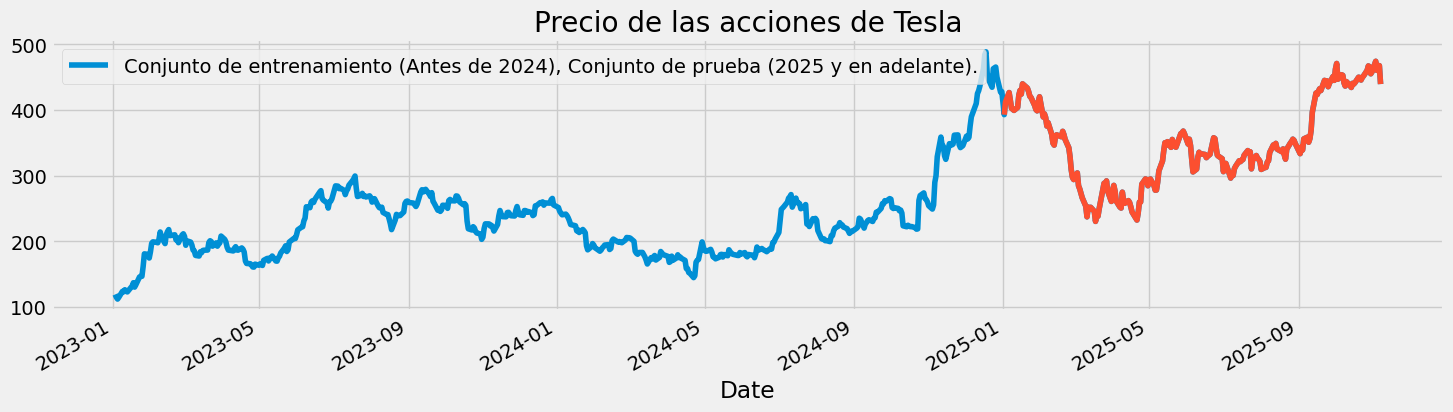

In [53]:
# Hemos elegido el atributo 'High' para los precios. Veamos cómo se ve.
dataset["High"][:'2025'].plot(figsize=(16,4), legend=True)  # Graficar los precios altos antes de 2025
dataset["High"]['2025':].plot(figsize=(16,4), legend=True)  # Graficar los precios altos a partir de 2025
plt.legend(['Conjunto de entrenamiento (Antes de 2024), Conjunto de prueba (2025 y en adelante).'])  # Leyenda del gráfico
plt.title('Precio de las acciones de Tesla')  # Título del gráfico
plt.show()  # Mostrar el gráfico

In [54]:
import plotly.graph_objects as go

# Crear un gráfico de velas (candlestick chart)
fig = go.Figure(data=[go.Candlestick(
    x=dataset.index,
    open=dataset['Open'],
    high=dataset['High'],
    low=dataset['Low'],
    close=dataset['Close'],
    increasing_line_color='green', decreasing_line_color='red',  # Colores para las velas
)])

# Agregar título y etiquetas
fig.update_layout(
    title='Tesla Stock Price (2023-2025)',
    xaxis_title='Fecha',
    yaxis_title='Precio de la acción (USD)',
    xaxis_rangeslider_visible=False  # Opcional: desactiva el control deslizante en el gráfico
)

# Mostrar el gráfico
fig.show()

Luego, los precios son normalizados (escalados) para que los valores estén entre 0 y 1 utilizando MinMaxScaler. Esto es importante para mejorar la eficiencia y el rendimiento del modelo de redes neuronales.

In [55]:
# Escalando el conjunto de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))  # Crear un objeto MinMaxScaler con un rango entre 0 y 1
training_set_scaled = sc.fit_transform(training_set)  # Ajustar y transformar el conjunto de entrenamiento


In [56]:
print(training_set_scaled.shape)


(502, 1)


# 4. Creación de la estructura de datos para el modelo:
La red LSTM necesita una secuencia de entradas para aprender de los patrones temporales. Por ello, se crean secuencias de 60 días de precios pasados (60 pasos de tiempo) y el precio de cierre correspondiente para cada secuencia.
Esto se hace en el bloque de código siguiente, donde se construye la entrada X_train y la salida y_train.


In [57]:
# Dado que los LSTM almacenan el estado de memoria a largo plazo, creamos una estructura de datos con 60 pasos de tiempo y 1 salida
# Así que, para cada elemento del conjunto de entrenamiento, tenemos 60 elementos previos del conjunto de entrenamiento
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):  # Usar len(training_set_scaled) en lugar de un número fijo
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)  # Convertir las listas en arrays de NumPy

In [58]:
X_train

array([[0.0187107 , 0.00753735, 0.        , ..., 0.2272884 , 0.21391227,
        0.22171499],
       [0.00753735, 0.        , 0.00700655, ..., 0.21391227, 0.22171499,
        0.22712917],
       [0.        , 0.00700655, 0.03123755, ..., 0.22171499, 0.22712917,
        0.25488997],
       ...,
       [0.3699939 , 0.36635789, 0.36946311, ..., 0.85660448, 0.93163298,
        0.93840064],
       [0.36635789, 0.36946311, 0.36646407, ..., 0.93163298, 0.93840064,
        0.89771489],
       [0.36946311, 0.36646407, 0.35685661, ..., 0.93840064, 0.89771489,
        0.83667293]])

Finalmente, X_train se reorganiza en una forma adecuada para la entrada de la red neuronal LSTM, que requiere una estructura de tres dimensiones (muestras, pasos de tiempo, características).

In [59]:
# Suponiendo que X_train tiene forma (n_samples, timesteps)
n_samples = X_train.shape[0]
timesteps = X_train.shape[1]
X_train = np.reshape(X_train, (n_samples, timesteps, 1))  # Añadir una dimensión
print(X_train.shape)

(442, 60, 1)


# 5. Construcción del modelo LSTM:
Se define un modelo de red neuronal secuencial con capas LSTM. Las redes LSTM son ideales para datos secuenciales como los precios de acciones, ya que pueden recordar información de pasos anteriores.
Se agregan 4 capas LSTM con regularización de Dropout para evitar el sobreajuste, y finalmente, una capa densa para obtener la salida (predicción del precio).

El modelo se compila utilizando el optimizador RMSprop y la función de pérdida

In [60]:
from keras.layers import Input

# La arquitectura de la red LSTM
regressor = Sequential()

# Primera capa Input para definir el tamaño de las entradas (60 neuronas)
regressor.add(Input(shape=(X_train.shape[1], 1)))

# Primera capa LSTM con regularización Dropout
regressor.add(LSTM(units=64, return_sequences=True))
regressor.add(Dropout(0.2))

# Segunda capa LSTM
regressor.add(LSTM(units=64, return_sequences=True))
regressor.add(Dropout(0.2))

# Tercera capa LSTM
regressor.add(LSTM(units=64, return_sequences=True))
regressor.add(Dropout(0.2))

# Cuarta capa LSTM
regressor.add(LSTM(units=64))
regressor.add(Dropout(0.2))

# Capa de salida
regressor.add(Dense(units=1))

# Compilando la red neuronal recurrente (RNN)
regressor.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=["mae"])


# 6. Entrenamiento del modelo:
El modelo se entrena utilizando el método .fit(), lo que ajusta el modelo a los datos de entrenamiento (X_train y y_train).
También se emplea un división de validación durante el entrenamiento (20%) para monitorear el rendimiento del modelo en datos no vistos mientras se entrena.

In [61]:
regressor.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Separar los últimos N días del entrenamiento como validación (por ejemplo, 20%)
split_index = int(len(X_train) * 0.8)
X_val, y_val = X_train[split_index:], y_train[split_index:]
X_train, y_train = X_train[:split_index], y_train[:split_index]

# Entrenar con validación explícita
history = regressor.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - loss: 0.0350 - mae: 0.1470 - val_loss: 0.0868 - val_mae: 0.2379
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0080 - mae: 0.0707 - val_loss: 0.0359 - val_mae: 0.1611
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0247 - mae: 0.1214 - val_loss: 0.0647 - val_mae: 0.1966
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0061 - mae: 0.0655 - val_loss: 0.1016 - val_mae: 0.2713
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0096 - mae: 0.0771 - val_loss: 0.0469 - val_mae: 0.1662
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0074 - mae: 0.0687 - val_loss: 0.0947 - val_mae: 0.2641
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0078 - mae: 0.0686 - val_loss: 0.0916 - val_mae: 0.2580
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0086 - mae: 0.0735 - val_loss: 0.0133 - val_mae: 0.0970
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.00

# 7. Graficar el history del entrenamiento:
Después de entrenar el modelo, se grafican las curvas de pérdida (loss) tanto para los datos de entrenamiento como para los de validación. Esto ayuda a ver si el modelo está aprendiendo de manera efectiva o si está sobreajustando los datos.
python
Copiar código


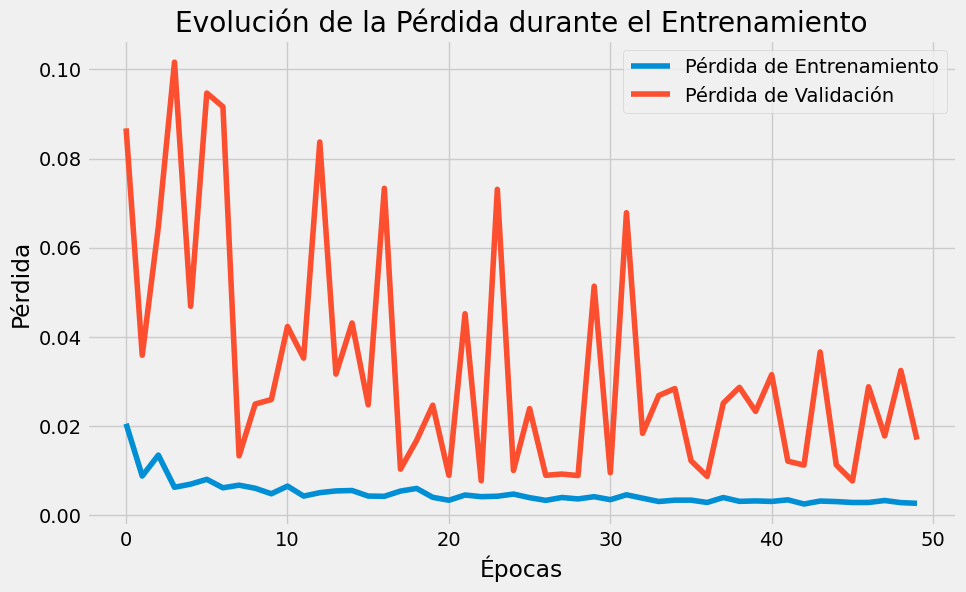

In [63]:
# Graficar el history de la pérdida de entrenamiento y validación
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()


In [64]:
# Preparar correctamente los datos para el conjunto de prueba
# Nota: usamos todo 2023 y 2024 como entrenamiento. Luego 2025 como prueba.
# Pero para crear las primeras 60 secuencias del test, necesitamos los últimos 60 datos del entrenamiento.

# Este paso toma las columnas 'High' para los años de entrenamiento
dataset_total = pd.concat((dataset["High"][:'2024'], dataset["High"]['2025':]), axis=0)

# Extraer los últimos 60 valores previos al test + el test completo (para construir secuencias de 60 pasos)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values

# Asegurarse de que tenga forma de columna
inputs = inputs.reshape(-1, 1)

# Normalizar con el mismo scaler usado en el entrenamiento
inputs_scaled = sc.transform(inputs)

# Crear estructura de datos para el test
X_test = []
for i in range(60, len(inputs_scaled)):
    X_test.append(inputs_scaled[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

**8. Gráficos adicionales:**
Se incluyen gráficos para visualizar los precios históricos de las acciones de Tesla, tanto para el conjunto de entrenamiento como para el conjunto de prueba, antes y después de 2024.
También, se muestra un gráfico tipo candlestick utilizando Plotly para visualizar los precios abiertos, cerrados, altos y bajos de las acciones de Tesla.

In [65]:
# Preparando X_test para la predicción
X_test = []
for i in range(60, len(inputs_scaled)):  # Usamos 60 pasos previos como entrada para cada predicción
    X_test.append(inputs_scaled[i-60:i, 0])  # Extraemos 60 datos previos

X_test = np.array(X_test)

# Verificar que X_test tenga la forma correcta antes de la redimensión
print("Forma de X_test antes de redimensionar:", X_test.shape)

# Redimensionamos X_test para que sea compatible con el modelo LSTM
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))  # La forma será (samples, timesteps, features)

# Verificamos la nueva forma de X_test
print("Forma de X_test después de redimensionar:", X_test.shape)

# Prediciendo los precios de las acciones usando el modelo entrenado
predicted_stock_price = regressor.predict(X_test)

# Desescalando las predicciones al rango original usando el scaler
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Verificamos las primeras predicciones
print("Primeras predicciones desescaladas:", predicted_stock_price[:5])


Forma de X_test antes de redimensionar: (214, 60)
Forma de X_test después de redimensionar: (214, 60, 1)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Primeras predicciones desescaladas: [[415.8185 ]
 [410.96658]
 [404.39438]
 [397.00964]
 [389.54532]]


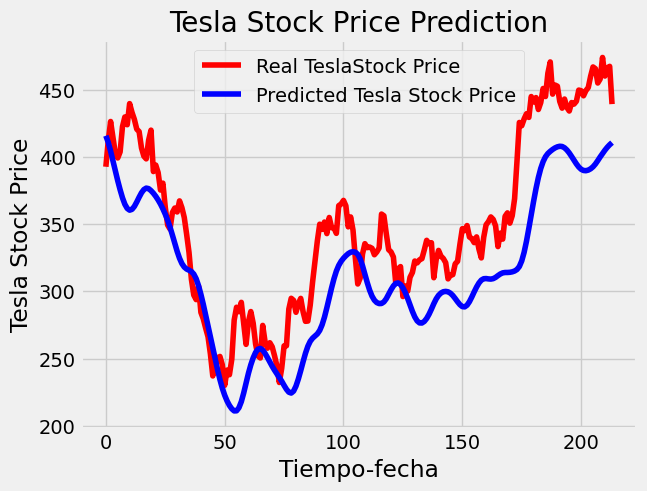

In [66]:

# Visualizando los resultados para LSTM
plot_predictions(test_set, predicted_stock_price)

In [67]:
import math
from sklearn.metrics import mean_squared_error

def return_rmse(test, predicted):
    # Calculamos el RMSE entre los valores reales y predichos
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("El error cuadrático medio (RMSE) es de: {}".format(rmse))

In [68]:
# Evaluar el modelo utilizando RMSE
return_rmse(test_set, predicted_stock_price)


El error cuadrático medio (RMSE) es de: 43.659148313356596


# Precio de las acciones usando GRU

In [69]:
from keras.layers import Input
from keras.optimizers import SGD

# Arquitectura de GRU con 100 unidades por capa
regressorGRU = Sequential()

# Capa de entrada
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

# Primera capa GRU con regularización Dropout
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Segunda capa GRU
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Tercera capa GRU
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Cuarta capa GRU
regressorGRU.add(GRU(units=100, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Capa de salida
regressorGRU.add(Dense(units=1))



# Compilando el modelo RNN sin 'decay' y con 'learning_rate' en lugar de 'lr'
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='mean_squared_error')


In [70]:
regressorGRU.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 60, 100)        │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 60, 100)        │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 100)            │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,801 (831.25 KB)

 Trainable params: 212,801 (831.25 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Ajustando el modelo con el conjunto de entrenamiento

# Entrenamiento del modelo GRU
history_gru = regressorGRU.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0569 - val_loss: 0.0407
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0217 - val_loss: 0.0072
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0124 - val_loss: 0.0078
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0118 - val_loss: 0.0062
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0100 - val_loss: 0.0056
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0097 - val_loss: 0.0063
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0094 - val_loss: 0.0051
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0051
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0080 - val_loss: 0.0053
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0074 - val_loss: 0.0045
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0067 - val_loss: 0.0052
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0075 - val_loss: 0.0045


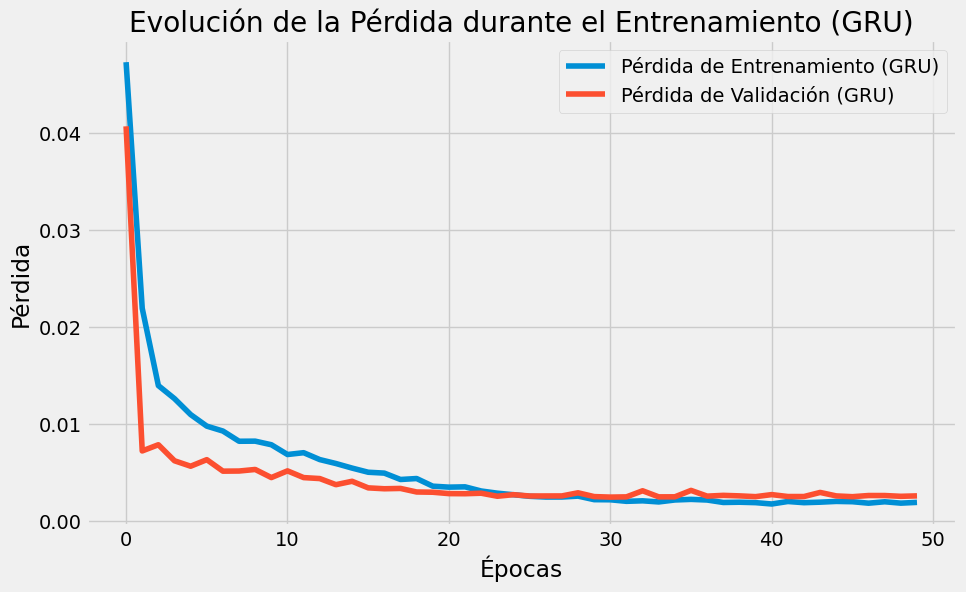

In [72]:
# Graficar el history de la pérdida de entrenamiento y validación para el modelo GRU
plt.figure(figsize=(10,6))
plt.plot(history_gru.history['loss'], label='Pérdida de Entrenamiento (GRU)')
plt.plot(history_gru.history['val_loss'], label='Pérdida de Validación (GRU)')
plt.title('Evolución de la Pérdida durante el Entrenamiento (GRU)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
# Preparando X_test para la predicción
X_test = []
for i in range(60, len(inputs_scaled)):  # Usamos 60 pasos previos como entrada para cada predicción
    X_test.append(inputs_scaled[i-60:i, 0])  # Extraemos 60 datos previos

X_test = np.array(X_test)

# Verificar que X_test tenga la forma correcta antes de la redimensión
print("Forma de X_test antes de redimensionar:", X_test.shape)

# Redimensionamos X_test para que sea compatible con el modelo LSTM
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))  # La forma será (samples, timesteps, features)

# Verificamos la nueva forma de X_test
print("Forma de X_test después de redimensionar:", X_test.shape)

# Prediciendo los precios de las acciones usando el modelo entrenado
GRUpredicted_stock_price = regressorGRU.predict(X_test)

# Desescalando las predicciones al rango original usando el scaler
GRUpredicted_stock_price = sc.inverse_transform(GRUpredicted_stock_price)

# Verificamos las primeras predicciones
print("Primeras predicciones desescaladas:", GRUpredicted_stock_price[:5])


Forma de X_test antes de redimensionar: (214, 60)
Forma de X_test después de redimensionar: (214, 60, 1)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
Primeras predicciones desescaladas: [[429.98138]
 [426.32474]
 [421.38623]
 [416.60388]
 [412.40427]]


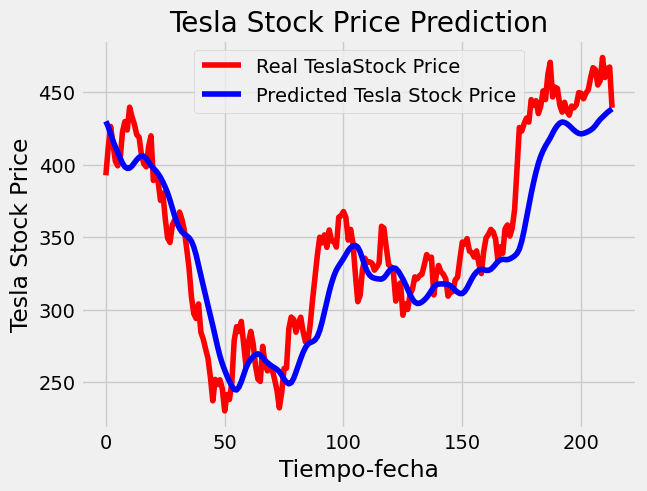

In [74]:
# Visualizando los resultados para GRU
plot_predictions(test_set, GRUpredicted_stock_price)

In [75]:
# Evaluando el modelo GRU
return_rmse(test_set, GRUpredicted_stock_price)


El error cuadrático medio (RMSE) es de: 27.647727921182693


In [76]:
from sklearn.metrics import r2_score
# Calcula el R^2 usando las predicciones y los valores reales
r2 = r2_score(test_set[60:], GRUpredicted_stock_price)

print("Coeficiente de determinación R²:", r2)

ValueError: Found input variables with inconsistent numbers of samples: [154, 214]

#Predecir los proximos 30 dias.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que tienes un dataset con un índice de fechas
dataset['Date'] = pd.to_datetime(dataset.index)

# Tomamos los últimos 60 días del conjunto de prueba para comenzar las predicciones
last_60_days = dataset['High'][-60:].values  # Asumiendo que 'High' es la columna de interés
last_60_days_scaled = sc.transform(last_60_days.reshape(-1, 1))  # Escalamos los datos

# Reshape de la secuencia inicial
last_60_days_scaled = last_60_days_scaled.reshape((1, 60, 1))  # Reshape para que sea compatible con LSTM

# Lista para almacenar las predicciones futuras
predicted_stock_price = []

# Realizamos las predicciones para los próximos 30 días
for i in range(30):  # Cambiar a 30 para predecir los próximos 30 días
    # Predicción del siguiente valor en la secuencia
    next_prediction = regressorGRU.predict(last_60_days_scaled)

    # Añadimos la predicción a la lista
    predicted_stock_price.append(next_prediction[0, 0])

    # Actualizamos la secuencia con la nueva predicción para la siguiente iteración
    last_60_days_scaled = np.append(last_60_days_scaled[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Desescalamos las predicciones al rango original
predicted_stock_price = sc.inverse_transform(np.array(predicted_stock_price).reshape(-1, 1))

# Generamos las fechas futuras a partir de la última fecha en el conjunto de prueba
last_date = dataset['Date'].iloc[-1]  # Última fecha del conjunto de datos
future_dates = pd.date_range(last_date, periods=31, freq='D')[1:]  # Generamos 30 fechas a partir de la última fecha

# Visualizamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(future_dates, predicted_stock_price, color='blue', label='Predicción futura (próximos 30 días)')
plt.title('Predicción de precios de Tesla para los próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel('Precio de la acción de Tesla (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


Entonces, GRU funciona mejor que LSTM en este caso. LSTM bidireccional también es una buena opción para hacer que el modelo sea más robusto. Pero esto puede variar según el conjunto de datos. Aplicar tanto LSTM como GRU juntos dio resultados aún mejores.


#Recomedaciones
## ¿Cómo se decide cuántas capas LSTM y cuántas neuronas usar?

Decidir cuántas capas LSTM y cuántas neuronas debe tener tu red LSTM depende de varios factores relacionados con el problema específico que estás resolviendo. No existe una única respuesta correcta, pero aquí te doy algunas pautas generales para tomar decisiones informadas.

### 1. **Número de capas LSTM**

El número de capas LSTM se elige según la **complejidad del problema**. Agregar más capas LSTM permite a la red aprender representaciones más abstractas y complejas de los datos, pero también incrementa el riesgo de **sobreajuste** (overfitting) y puede hacer que el modelo sea más difícil de entrenar.

#### Pautas comunes:
- **Redes más profundas** (más capas LSTM) son útiles cuando:
  - El problema es **muy complejo**, como en tareas de procesamiento de lenguaje natural (PLN), traducción de idiomas, etc.
  - Los datos tienen patrones temporales complejos que requieren múltiples capas para modelar adecuadamente.
  
- **Redes más simples** (menos capas LSTM) son más efectivas cuando:
  - El problema es **relativamente sencillo**, como tareas de predicción de series temporales.
  - Tienes pocos datos, ya que una red más profunda puede llevar a sobreajuste con pocos datos.

#### En la práctica:
- Comienza con **1 o 2 capas LSTM**. Si el modelo no está aprendiendo bien, puedes agregar más capas.
- En la mayoría de los casos, **2 a 4 capas LSTM** es una configuración común.

### 2. **Número de neuronas en cada capa LSTM**

El número de neuronas en cada capa LSTM se refiere a cuántas **unidades de memoria** tiene la red para aprender y representar secuencias de datos. Este valor también es un parámetro ajustable.

#### Factores a considerar:
- **Mayor número de neuronas**: permite que la red tenga más capacidad para aprender representaciones complejas de los datos, pero también aumenta el número de parámetros y el riesgo de sobreajuste si no se tiene suficiente cantidad de datos.
- **Menor número de neuronas**: hace que el modelo sea más simple y menos propenso a sobreajuste, pero puede no tener suficiente capacidad para aprender relaciones complejas.

#### Pautas comunes:
- Comienza con un número moderado de neuronas, como **50 o 100**.
- Si el modelo es demasiado simple y no aprende bien, intenta aumentar el número de neuronas.
- Si estás trabajando con secuencias más largas o complejas, puedes considerar usar más neuronas (por ejemplo, **200 o 300**), pero ten en cuenta que esto incrementa el tiempo de entrenamiento y el riesgo de sobreajuste.
- Si tienes pocos datos, es mejor comenzar con **menos neuronas** (por ejemplo, 30 a 50).

### 3. **Ajustando el número de capas y neuronas con validación cruzada**

La mejor manera de decidir el número de capas y neuronas es mediante **experimentación**. Generalmente, se realiza validación cruzada para evaluar cómo cambia el rendimiento del modelo a medida que ajustas estos hiperparámetros.

#### Pasos típicos:
- **Dividir los datos** en entrenamiento y validación.
- **Entrenar el modelo** con diferentes configuraciones (por ejemplo, 1, 2 o 3 capas LSTM con 50, 100, o 200 neuronas).
- **Evaluar el modelo** en el conjunto de validación.
- Elegir la configuración que **mejor generalice** en el conjunto de validación.

### 4. **Consideraciones adicionales**

Otros factores también pueden influir en la elección del número de capas y neuronas:

- **Cantidad de datos**: Si tienes un conjunto de datos pequeño, probablemente necesitarás un modelo más simple (menos capas y menos neuronas). Si tienes grandes volúmenes de datos, puedes permitirte redes más grandes.
- **Regularización**: Si estás usando **dropout**, **normalización** o **early stopping**, puedes permitirte usar más capas y neuronas sin sobreajustar tanto.
- **Tiempo de entrenamiento**: Modelos más grandes con más capas y neuronas son más lentos de entrenar, lo que puede ser un factor limitante.

### 5. **Ajuste de hiperparámetros con técnicas avanzadas**

Para optimizar aún más el modelo, puedes usar técnicas de **búsqueda de hiperparámetros** como:

- **Búsqueda aleatoria** (`Random Search`).
- **Búsqueda en cuadrícula** (`Grid Search`).
- **Optimización bayesiana** (con herramientas como **Optuna** o **Keras Tuner**).

### Resumen de consideraciones:

- **Número de capas LSTM**:
  - Comienza con 1 o 2 capas.
  - Más capas son útiles para problemas más complejos, pero pueden llevar a sobreajuste si no tienes suficientes datos.
- **Número de neuronas**:
  - Comienza con 50 o 100 neuronas por capa.
  - Aumenta las neuronas si el modelo necesita mayor capacidad, pero vigila el sobreajuste.
- **Experimentación**: Siempre valida tu modelo con un conjunto de datos de validación y ajusta según los resultados. Puedes probar diferentes configuraciones utilizando técnicas de búsqueda de hiperparámetros.

### Ejemplo de experimentación con Keras:

En Keras, puedes experimentar con diferentes configuraciones de capas y neuronas fácilmente:

```python
# Ejemplo con 1 capa LSTM
model_1 = Sequential()
model_1.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model_1.add(Dense(units=1))

# Ejemplo con 2 capas LSTM
model_2 = Sequential()
model_2.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_2.add(LSTM(units=50, return_sequences=False))
model_2.add(Dense(units=1))

# Compilar y entrenar ambos modelos
model_1.compile(optimizer='adam', loss='mean_squared_error')
model_2.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento (en cada modelo)
model_1.fit(X_train, y_train, epochs=10, batch_size=32)
model_2.fit(X_train, y_train, epochs=10, batch_size=32)




```python

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV

# Función para crear el modelo - sin valores por defecto en los hiperparámetros a optimizar
def create_model(units, dropout_rate):
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units, return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(units=1))
    model.compile(optimizer='rmsprop', loss='mean_squared_error')
    return model

# Envolver el modelo
model = KerasRegressor(build_fn=create_model, verbose=0)

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'units': [50, 100],
    'dropout_rate': [0.2, 0.3],
    'batch_size': [32],  # Puedes expandir si quieres más combinaciones
    'epochs': [50]
}

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)

# Entrenar búsqueda
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación (media de validación):", grid_search.best_score_)

# Evaluación del mejor modelo en X_test
best_model = grid_search.best_estimator_
test_loss = best_model.score(X_test, y_test)
print("Pérdida en el conjunto de prueba:", test_loss)

```



In [ ]:
import re
from IPython import get_ipython

# Get the content of all code cells
code_cells = []
shell = get_ipython()
if hasattr(shell, '_get_cell_contents'):
    for cell_id in shell._get_cell_ids():
        if shell._get_cell_type(cell_id) == 'code':
            code_cells.append(shell._get_cell_contents(cell_id))
else:
    print("Warning: Could not retrieve cell contents. Falling back to less precise method.")
    # Fallback if _get_cell_contents is not available (less likely in Colab)
    # This part might not be needed in most Colab environments but is a safeguard
    # You might need to manually inspect cells or rely on pip freeze
    pass


# Extract imported libraries
imported_libraries = set()
for cell_source in code_cells:
    # Find import statements
    imports = re.findall(r'^\s*import\s+([a-zA-Z_][a-zA-Z0-9_]*)|^from\s+([a-zA-Z_][a-zA-Z0-9_]*)\s+import', cell_source, re.MULTILINE)
    for imp in imports:
        # Add the library name (handle both import and from ... import)
        if imp[0]:
            imported_libraries.add(imp[0])
        elif imp[1]:
            imported_libraries.add(imp[1])

print("Identified imported libraries:", imported_libraries)

In [ ]:
# Get the first sample from y (which is a single one-hot encoded vector)
first_label_one_hot = y[0, :]

# Find the index where the value is True
index = np.argmax(first_label_one_hot)

# Convert the index back to a character using the idx2char dictionary
character = idx2char[index]

print("Original one-hot encoded label shape:", first_label_one_hot.shape)
print("Index:", index)
print("Character:", character)